# RAW and way for subtrction analysis



In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.time import Time
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import glob

folder1 = "/content/drive/MyDrive/Colab Notebooks/RT/20260211/FITS"
folder2 = "/content/drive/MyDrive/Colab Notebooks/RT/20260212/FITS"
fits_files1 = sorted(glob.glob(f"{folder1}/*.fits"))
fits_files2 = sorted(glob.glob(f"{folder2}/*.fits"))

DIAMETER =                    0  / TELESCOPE diameter                            [astropy.io.fits.card]
DIAMETER =                    0  / TELESCOPE diameter                           


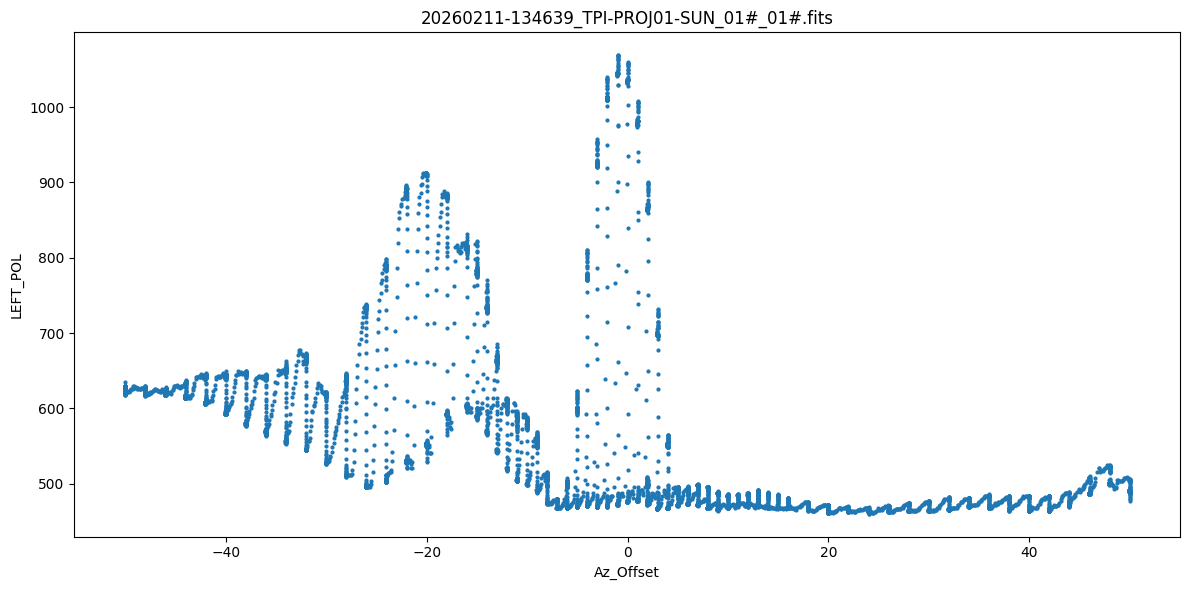

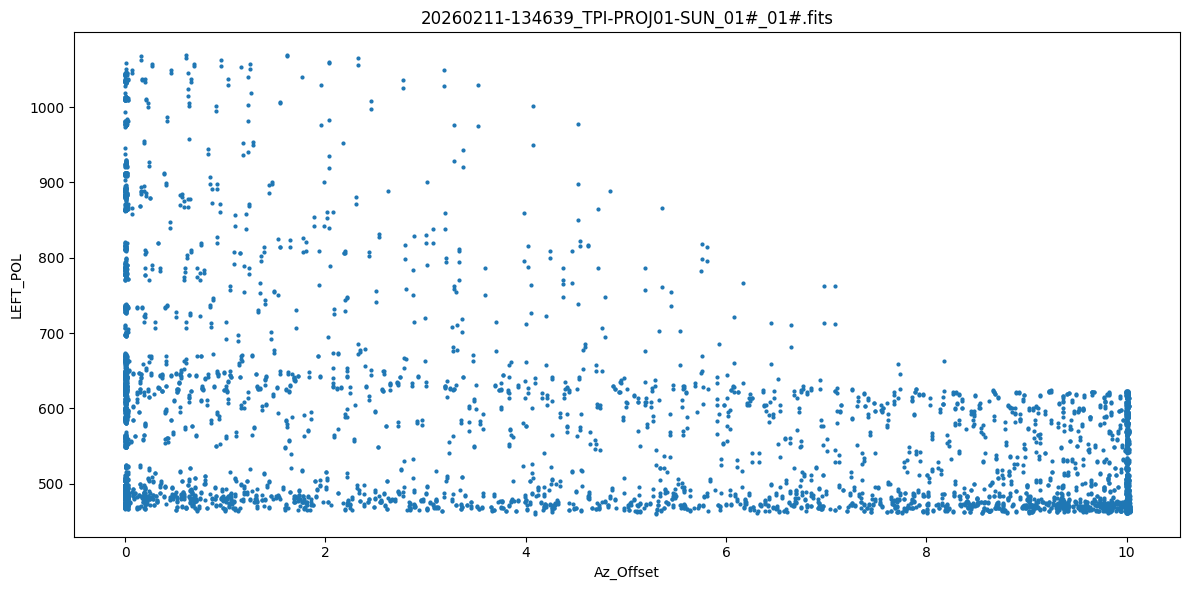

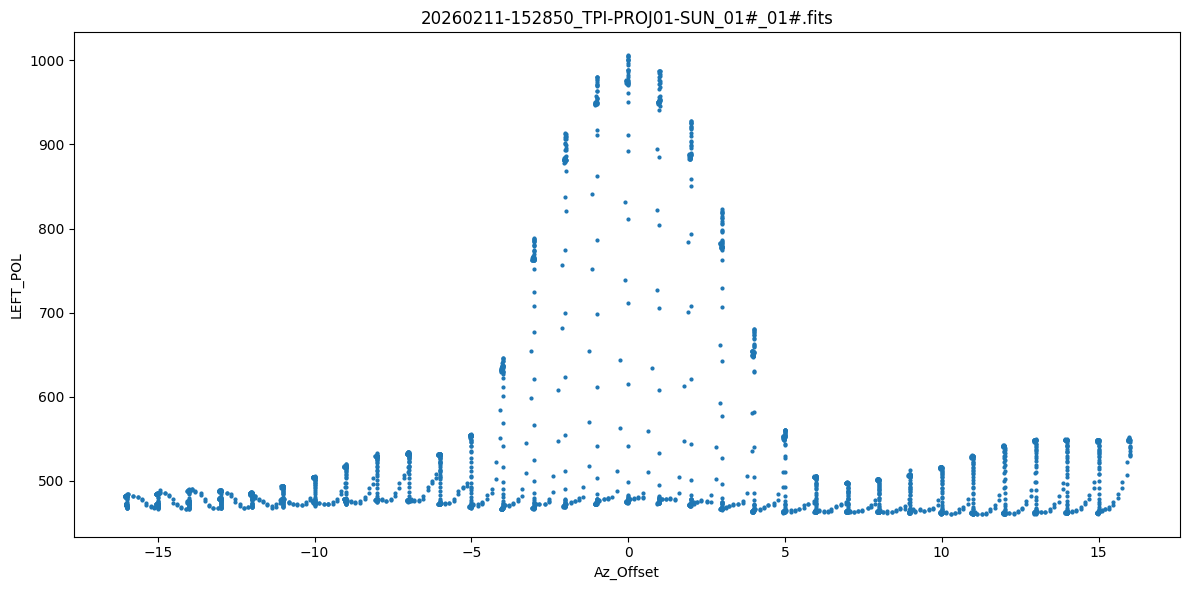

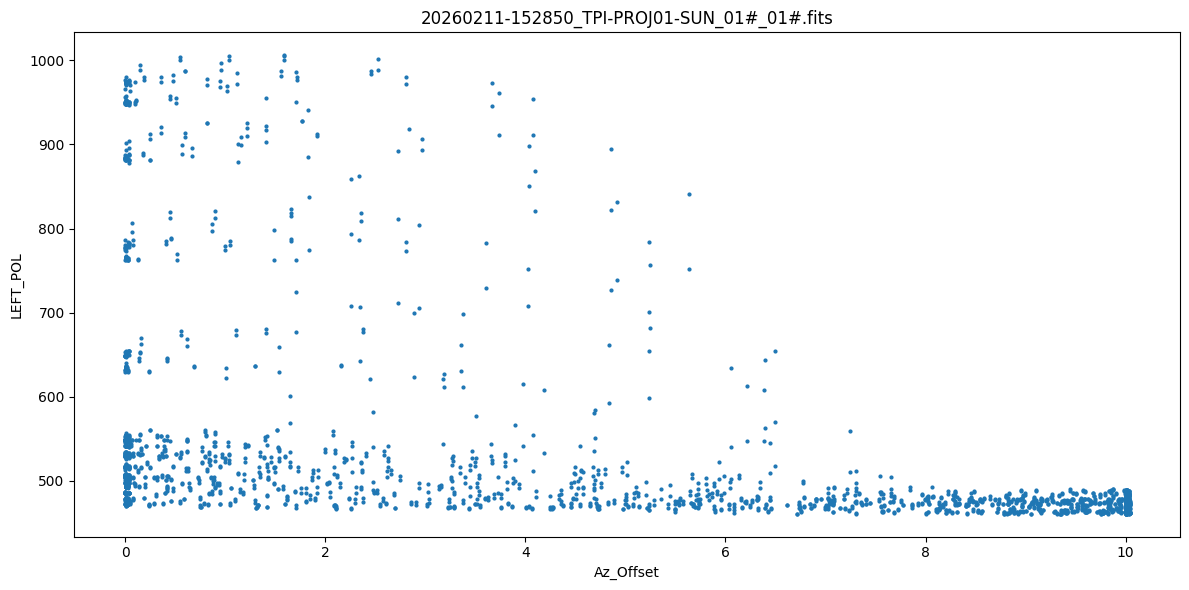

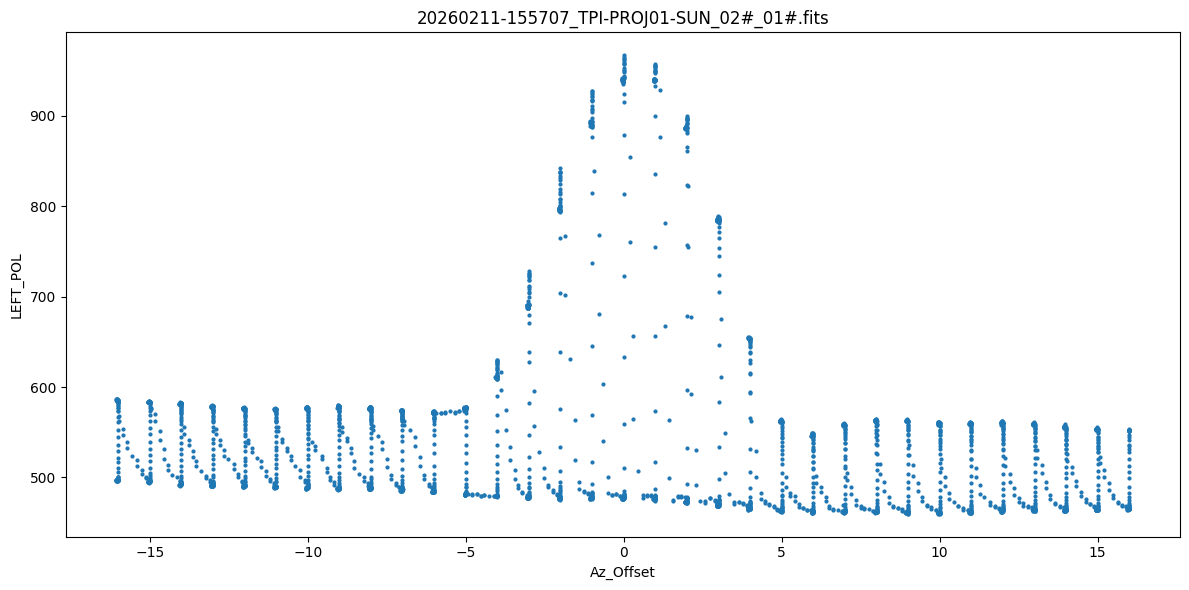

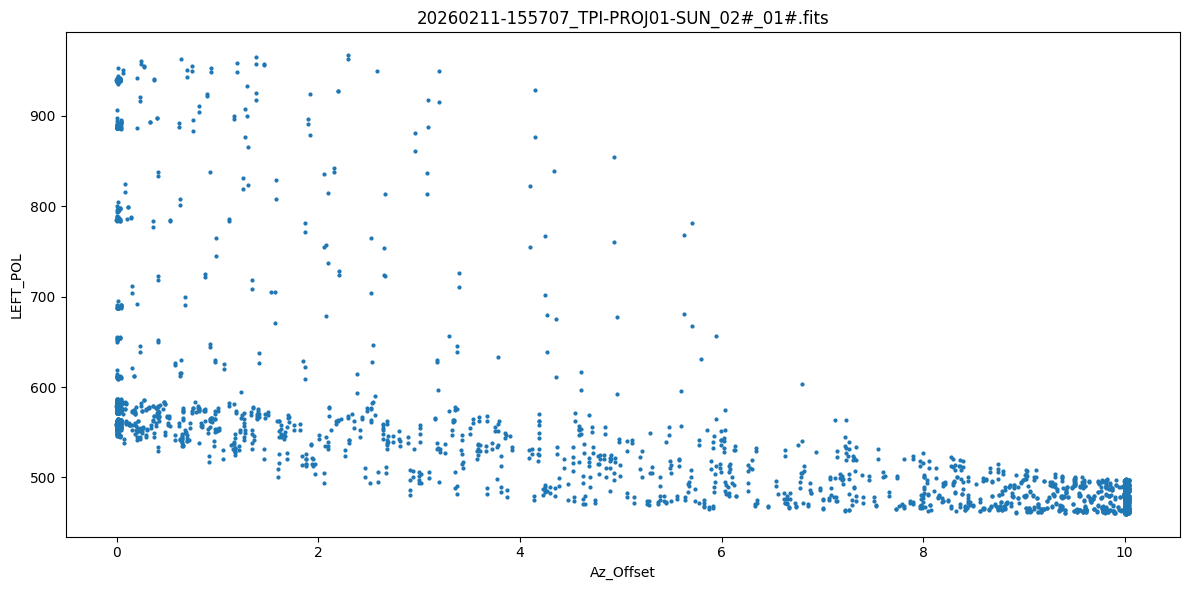

DIAMETER =                    3  / TELESCOPE diameter                            [astropy.io.fits.card]
DIAMETER =                    3  / TELESCOPE diameter                           


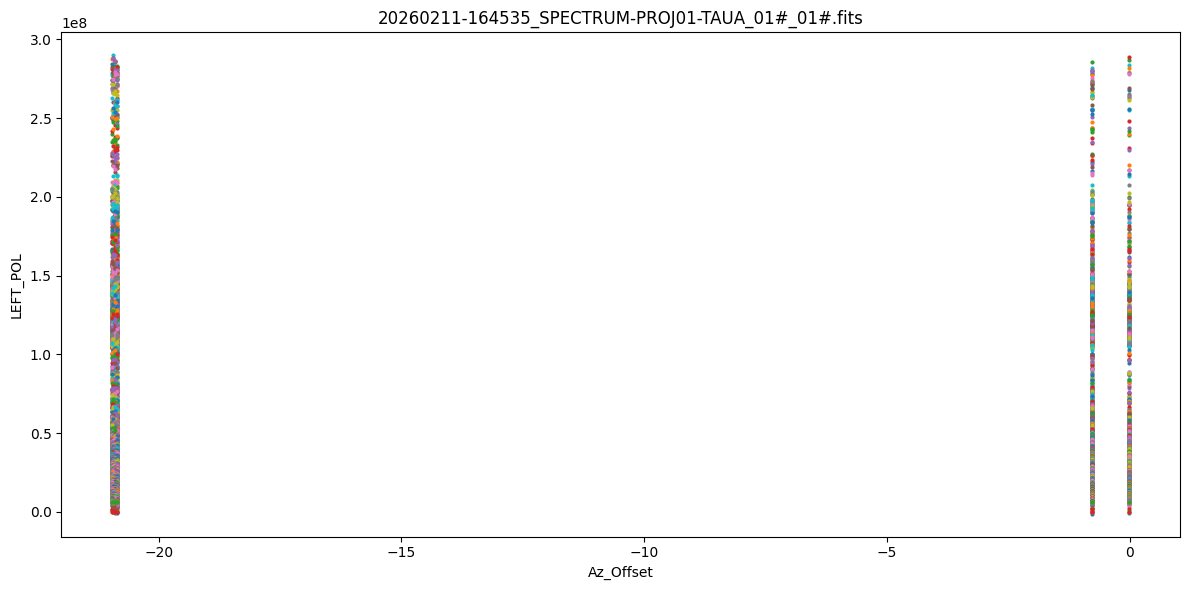

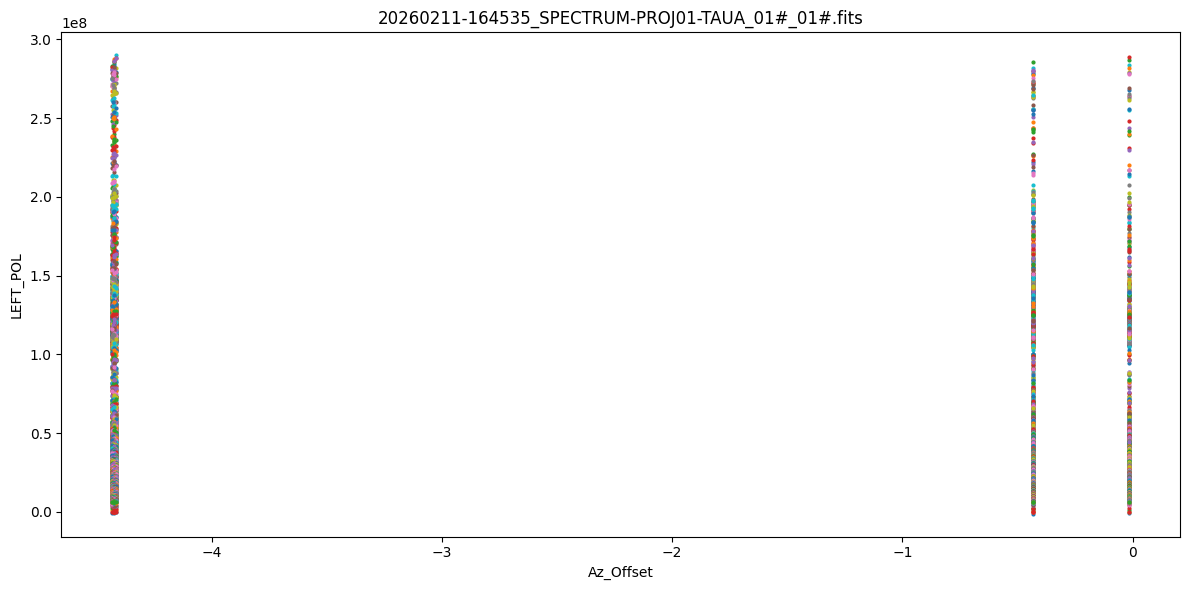

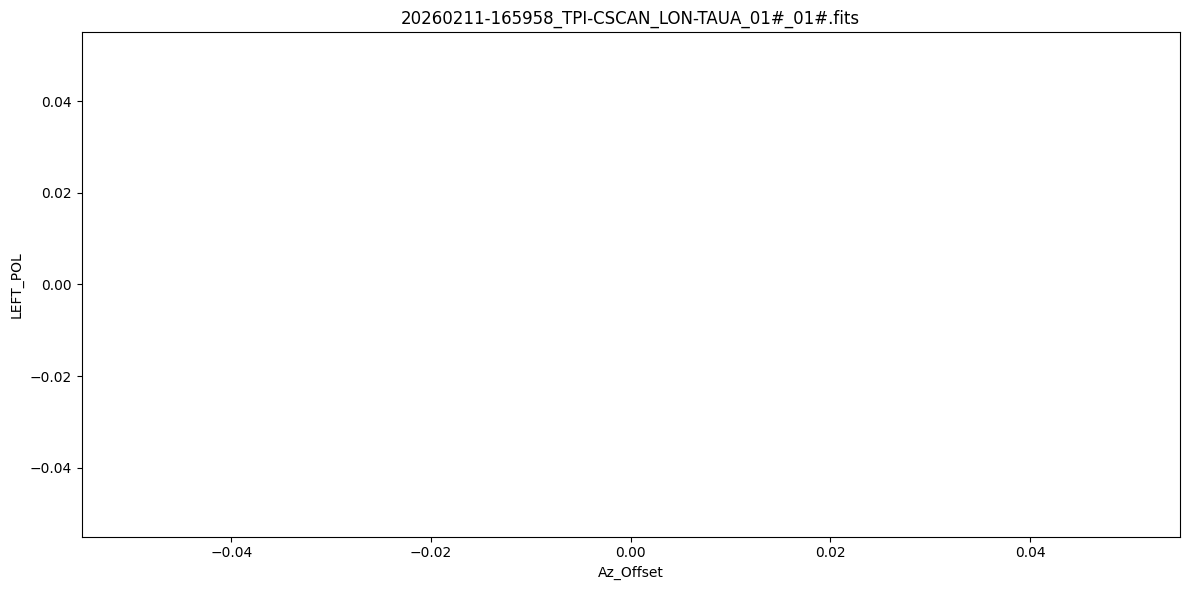

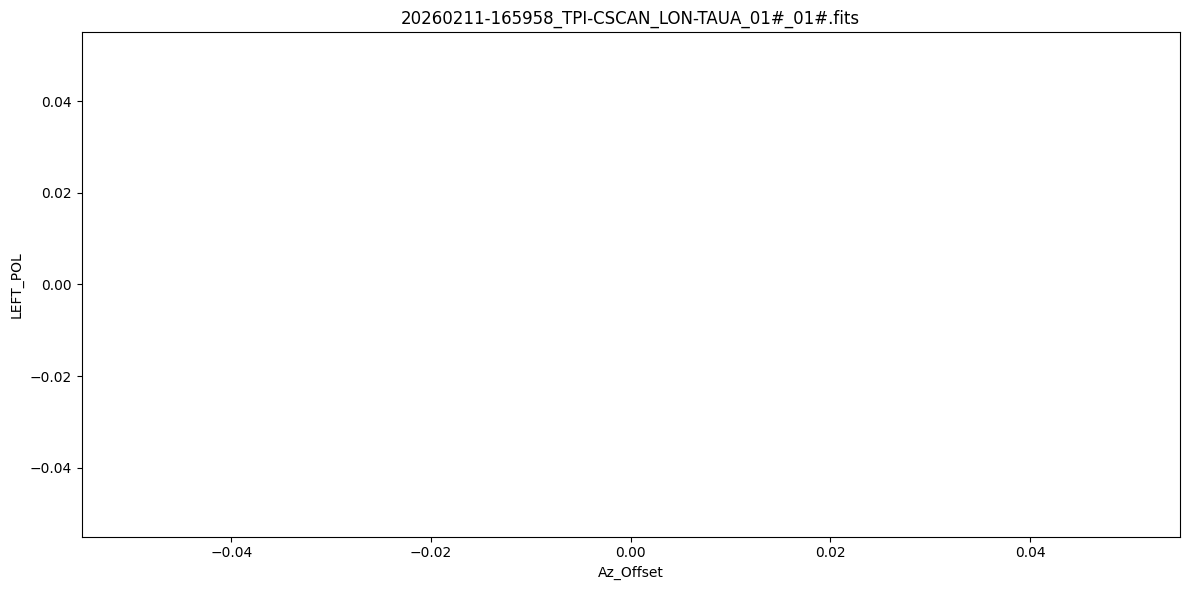

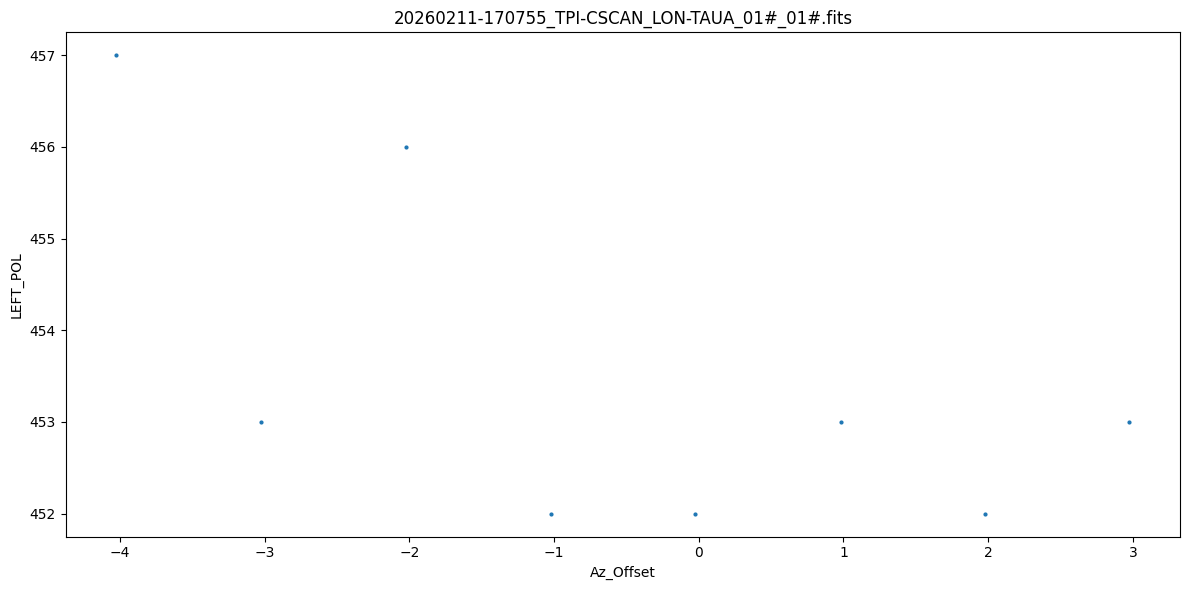

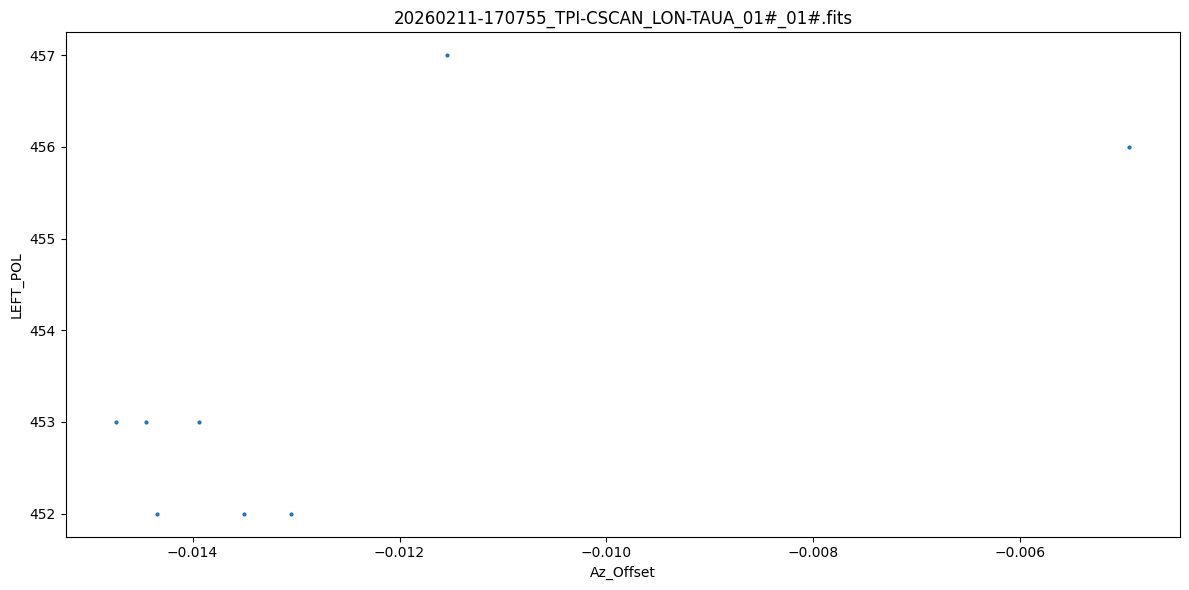

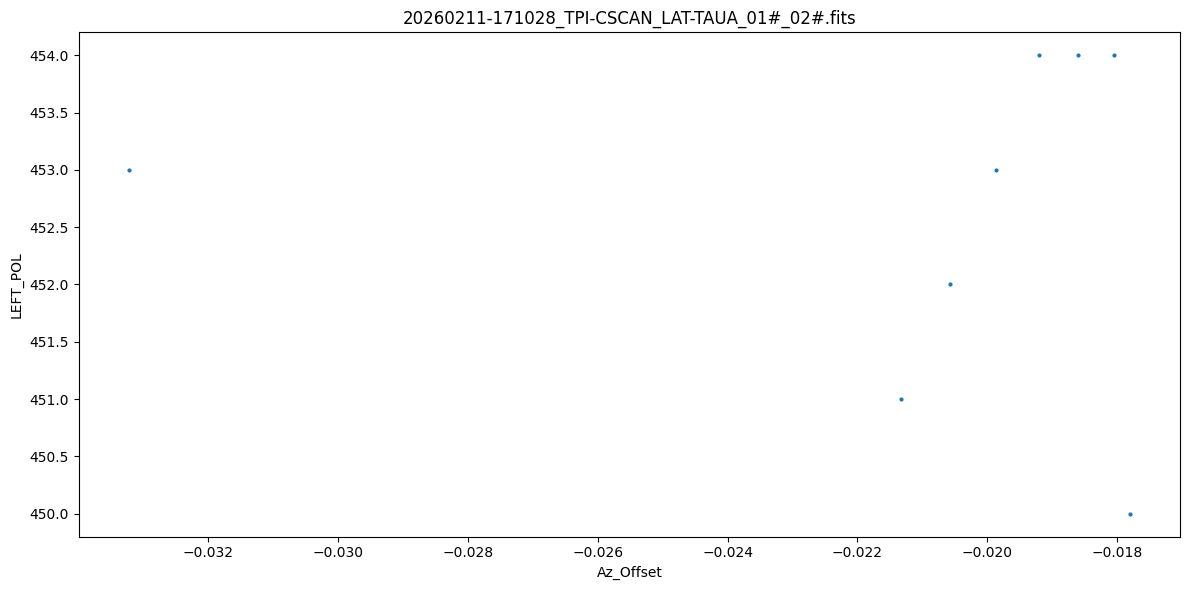

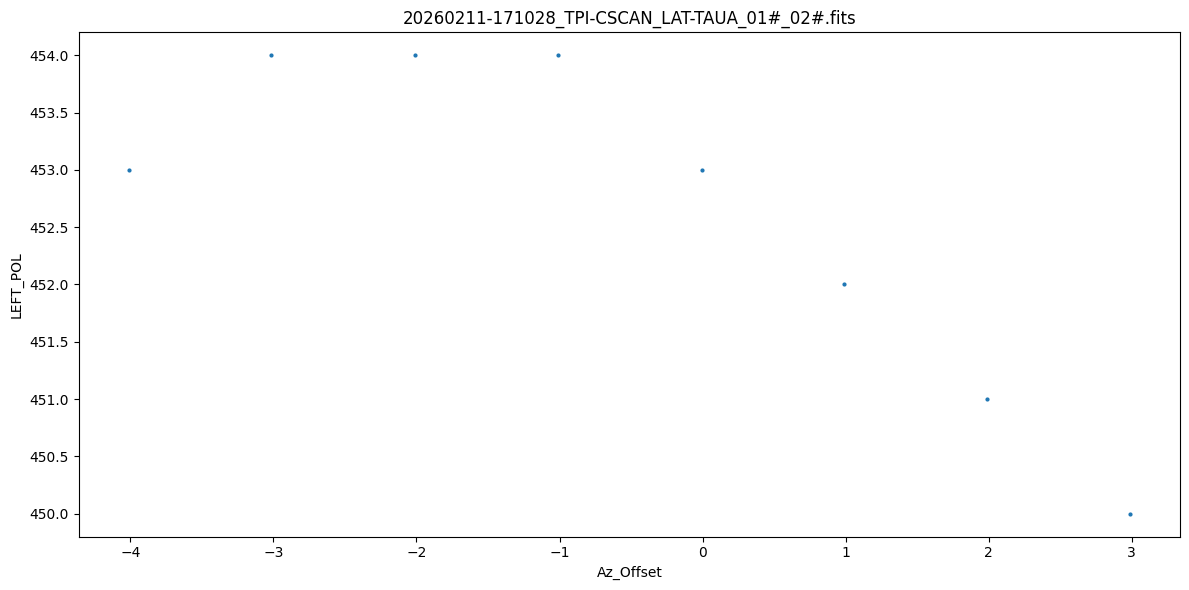

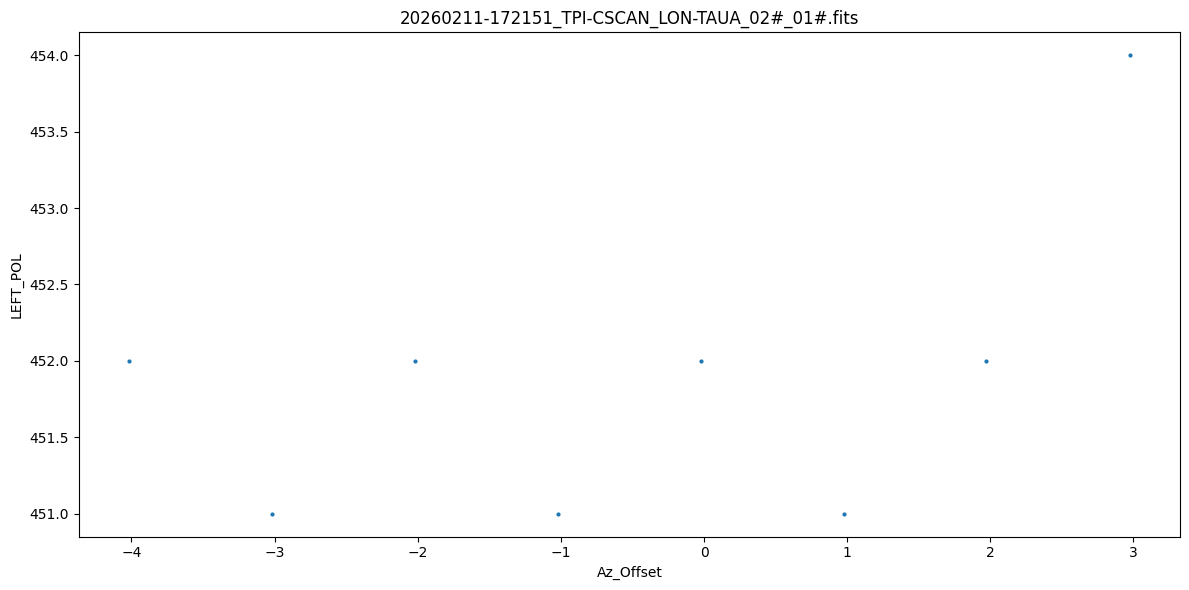

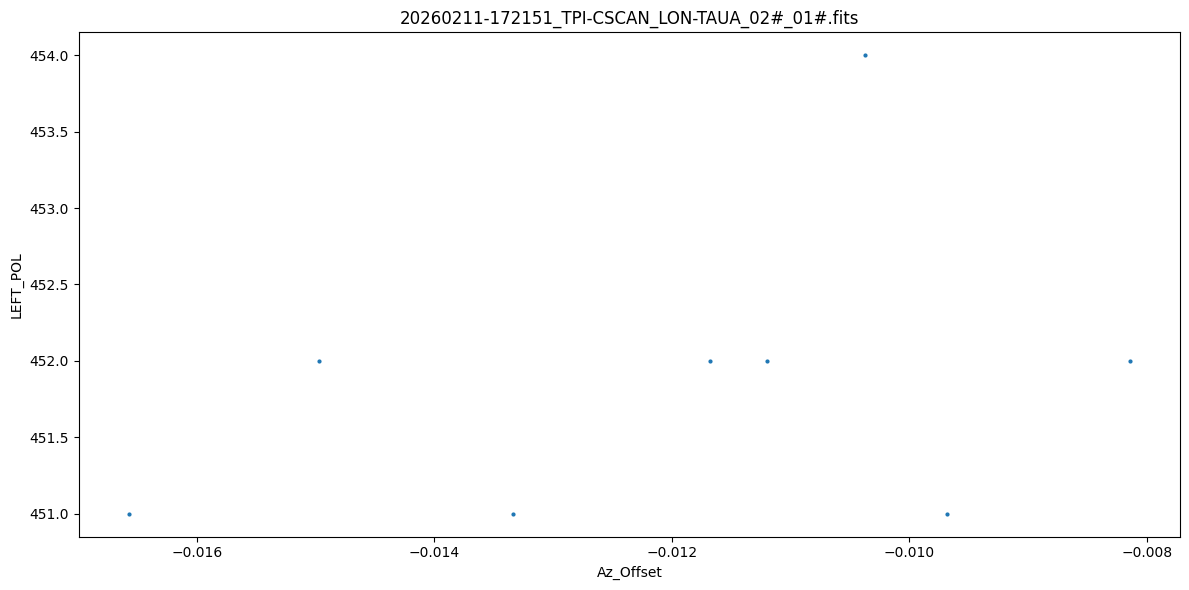

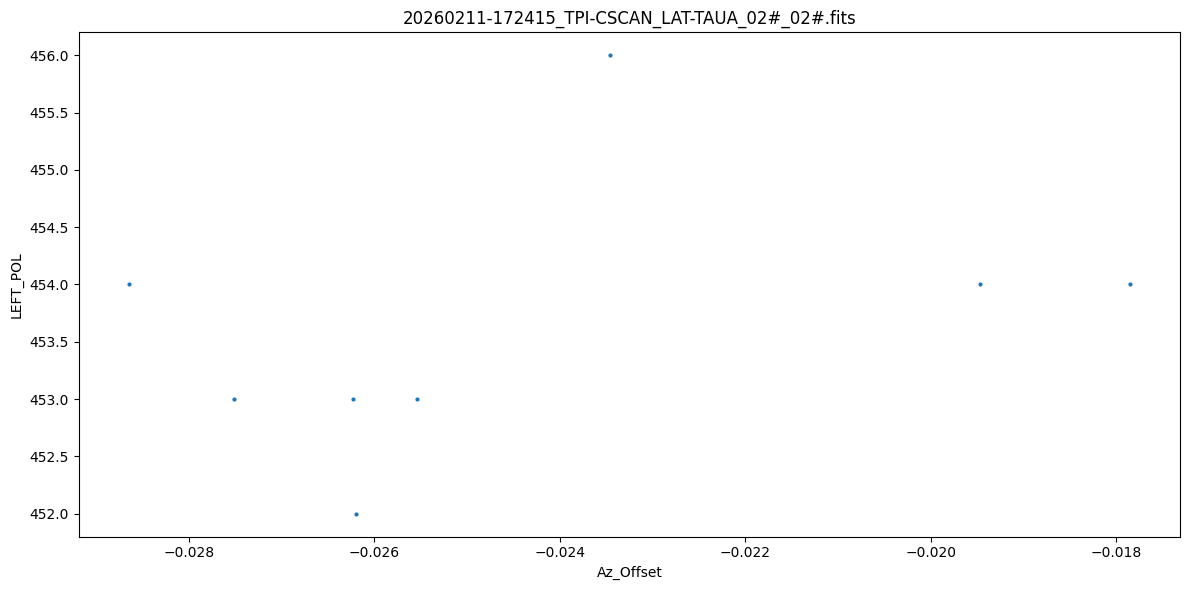

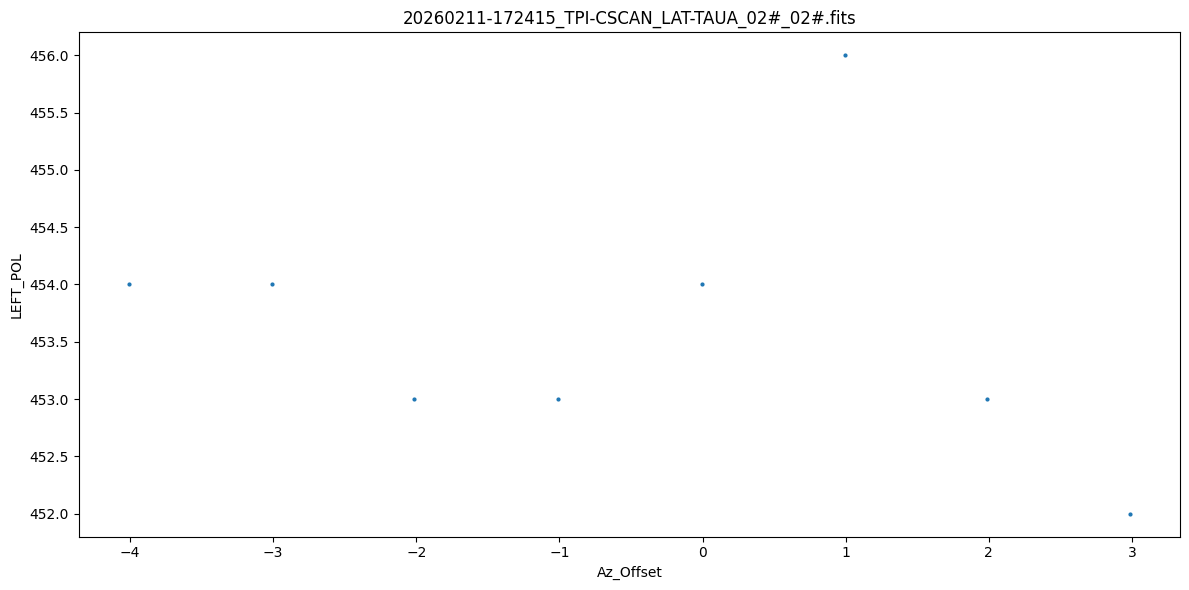

In [3]:
for fname in fits_files1[0:]:
    with fits.open(fname) as hdul:
        data = hdul[1].data
        hdr = hdul[0].header  # Access header from primary HDU (index 0)
        x1 = data["Az_Offset"]
        x2 = data["El_Offset"]
        y = data["LEFT_POL"]
        #t = Time(data["JD"][0], format="jd")
        #time_str = t.iso.split(".")[0]

        plt.figure(figsize=(12,6))
        plt.plot(x1, y, ".", ms=4)
        plt.title(fname.split("/")[-1])
        plt.xlabel("Az_Offset")
        plt.ylabel("LEFT_POL")
        plt.tight_layout()
        plt.show()

        #check the off set range
        plt.figure(figsize=(12,6))
        plt.plot(x2, y, ".", ms=4)
        plt.title(fname.split("/")[-1])
        plt.xlabel("Az_Offset")
        plt.ylabel("LEFT_POL")
        plt.tight_layout()
        plt.show()

DIAMETER =                    0  / TELESCOPE diameter                            [astropy.io.fits.card]
DIAMETER =                    0  / TELESCOPE diameter                           


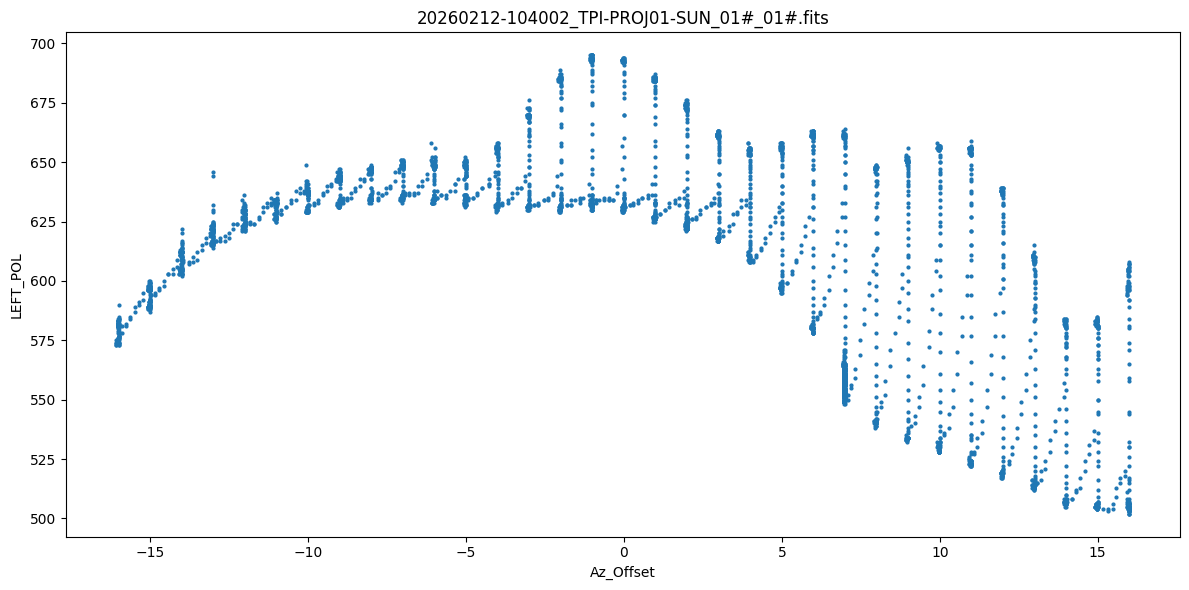

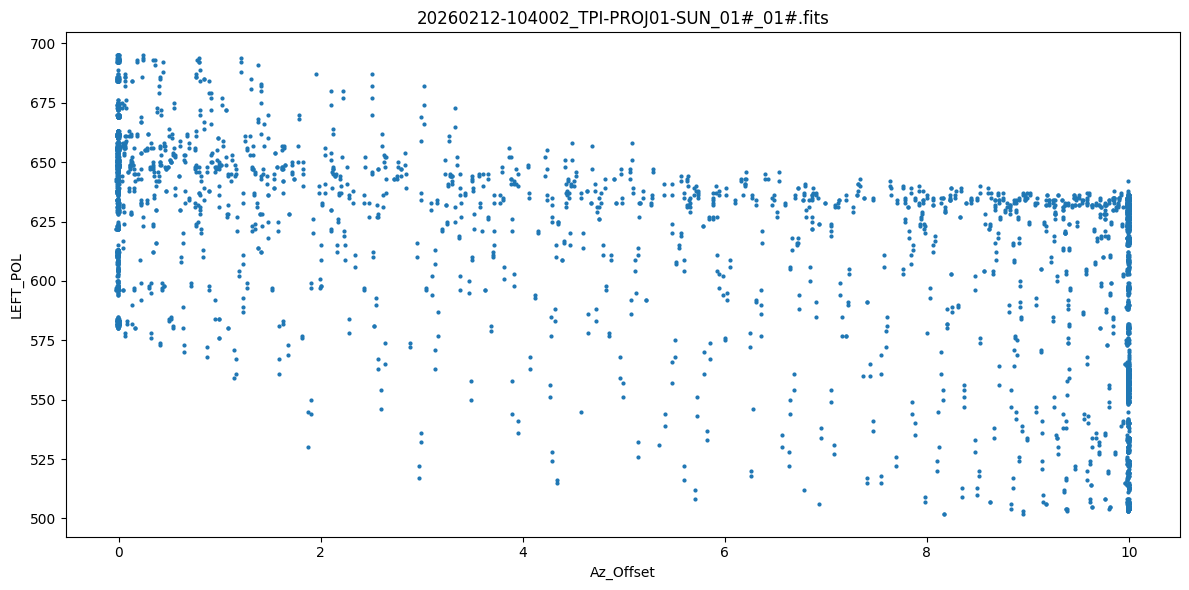

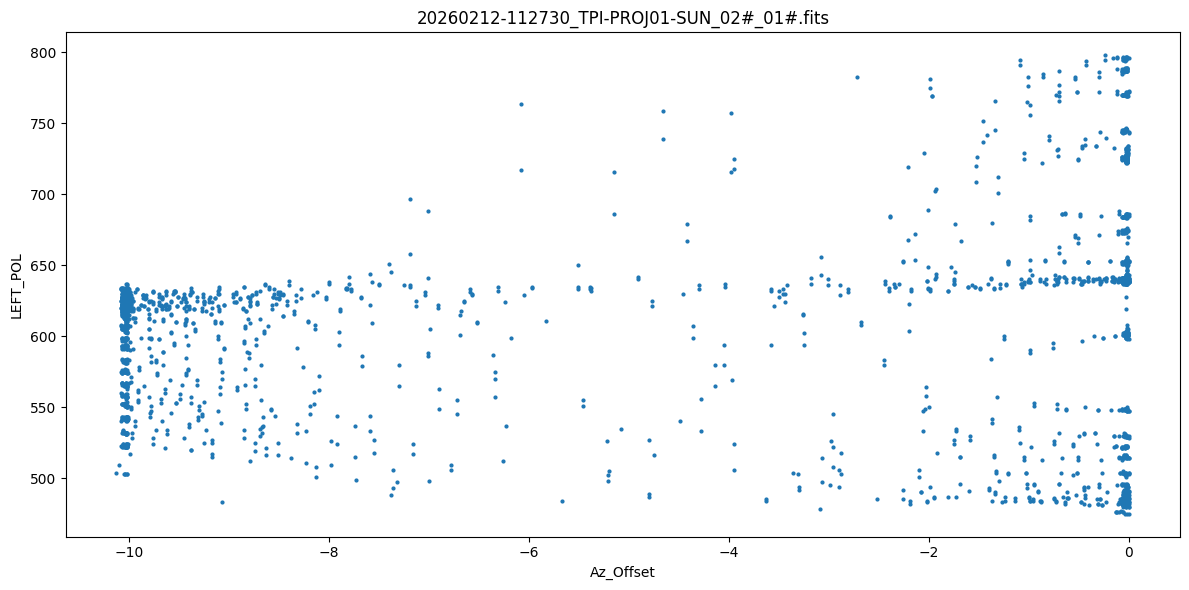

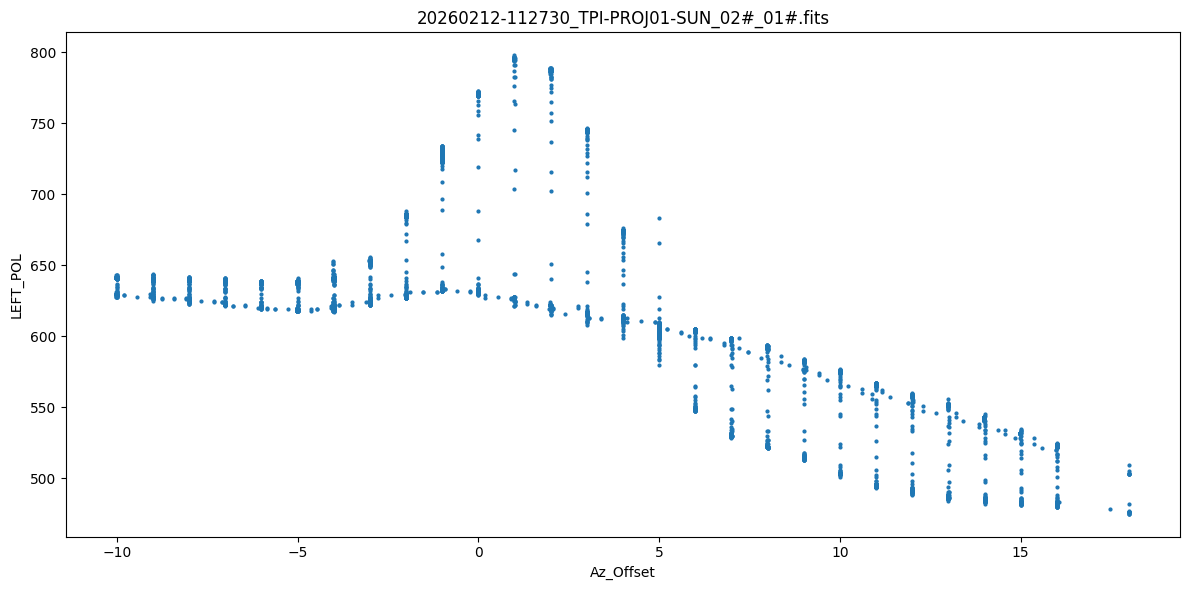

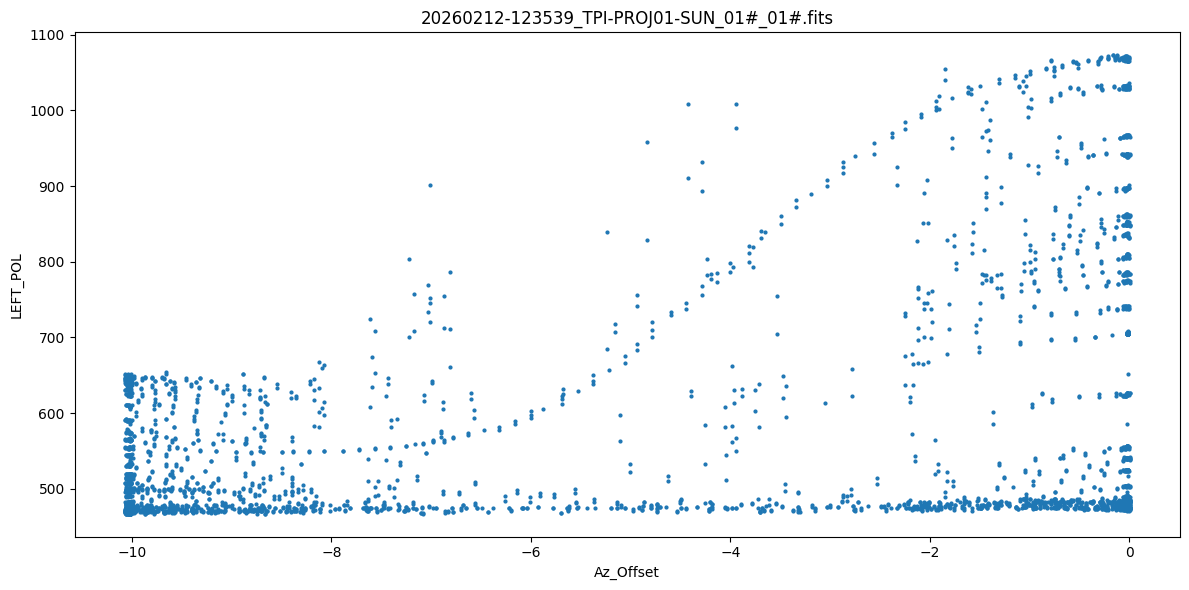

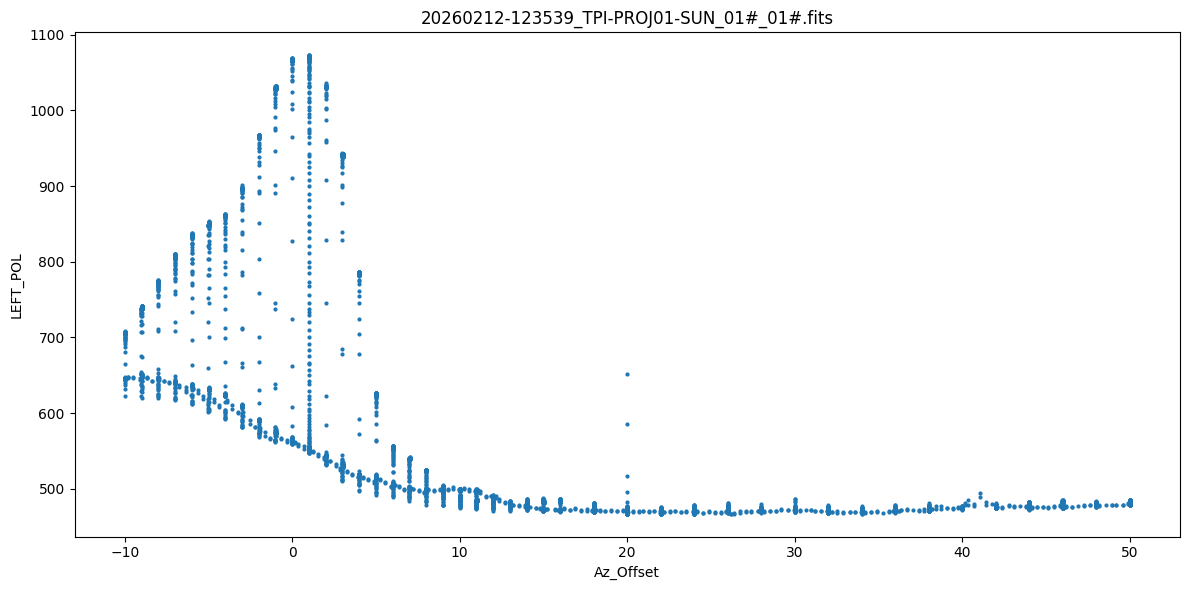

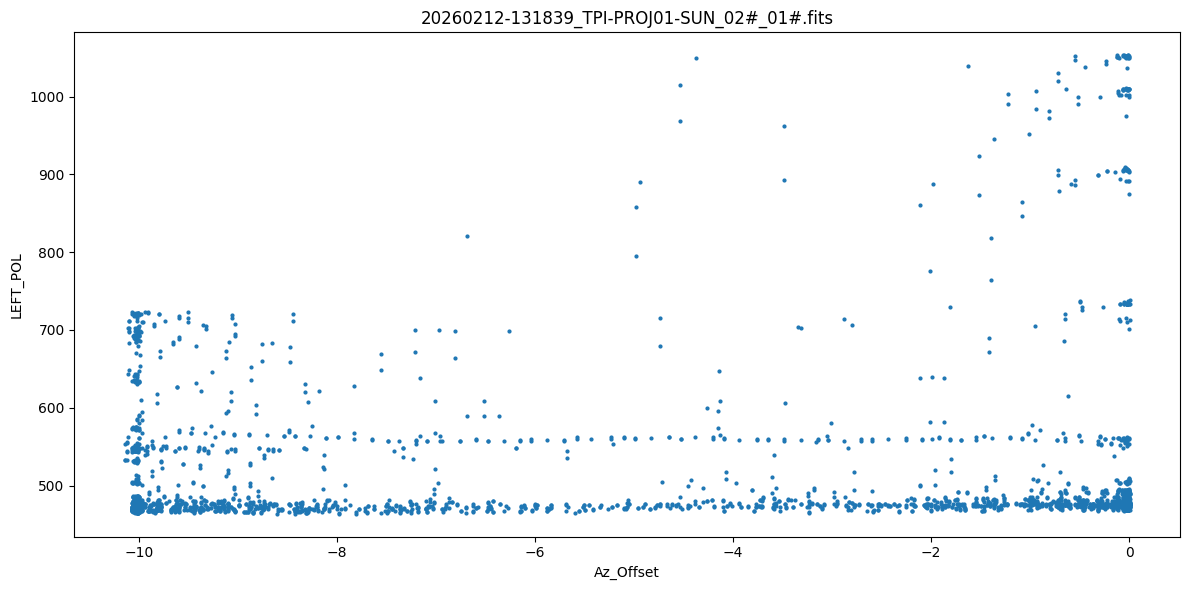

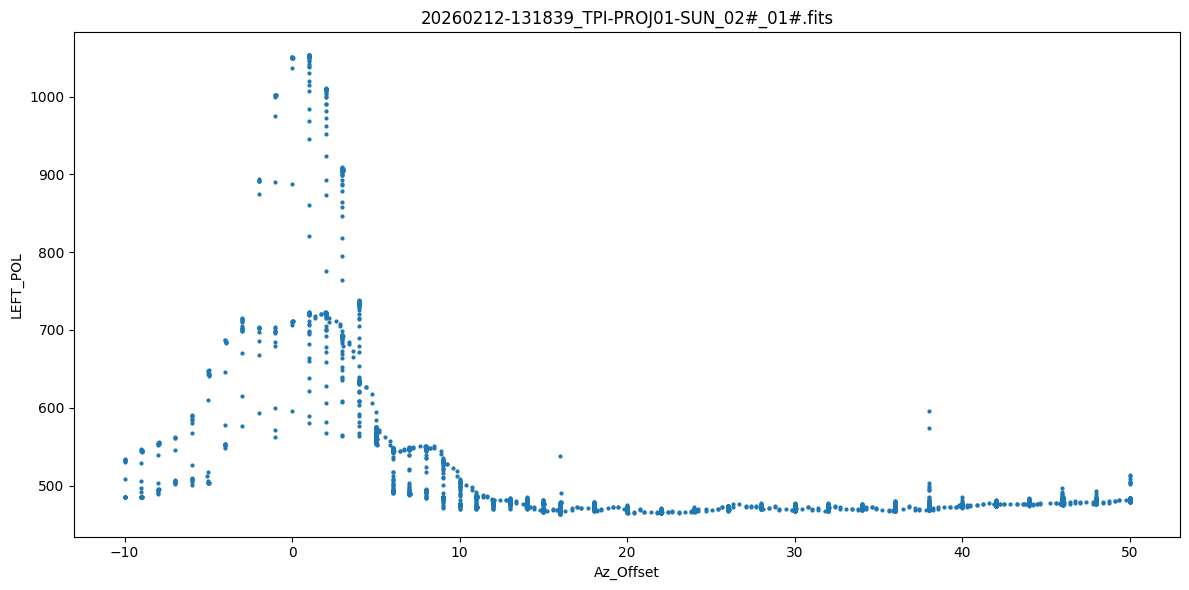

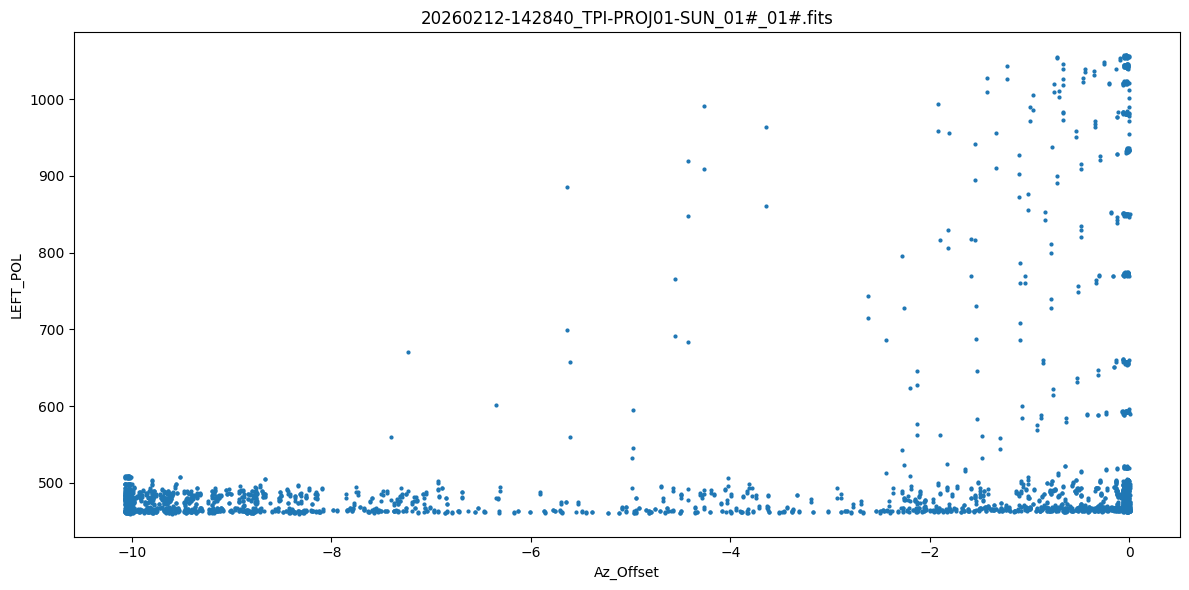

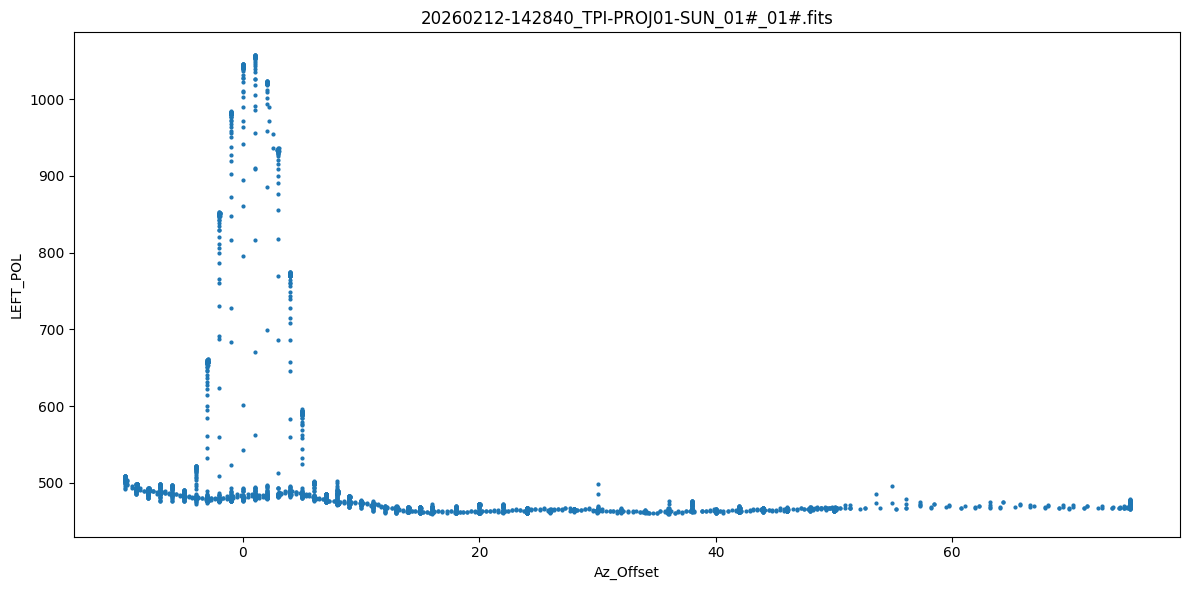

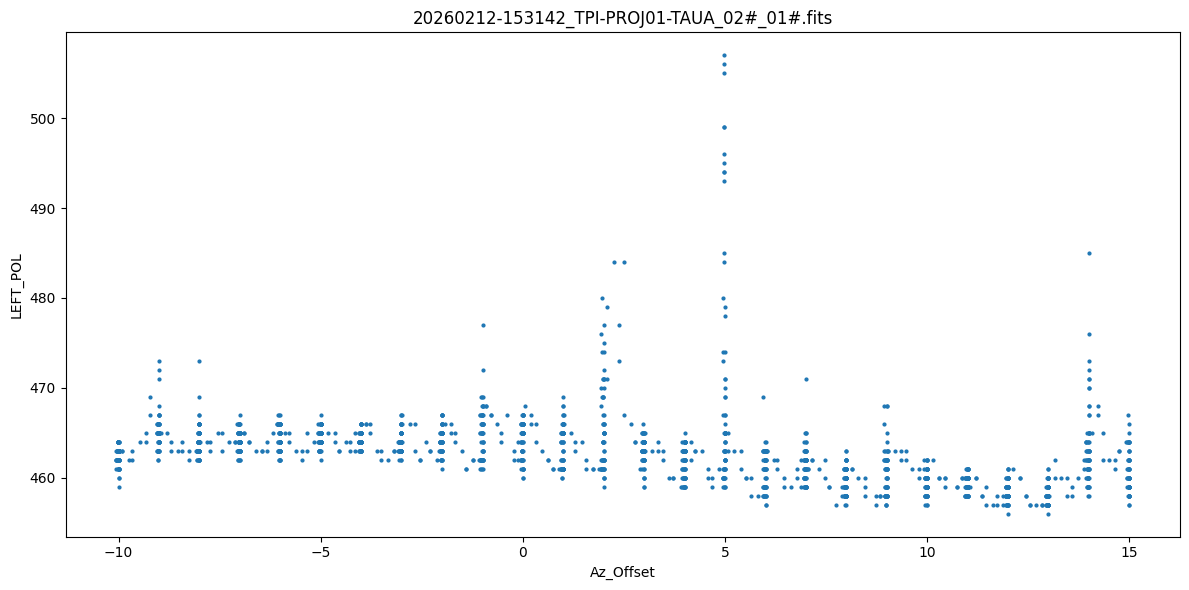

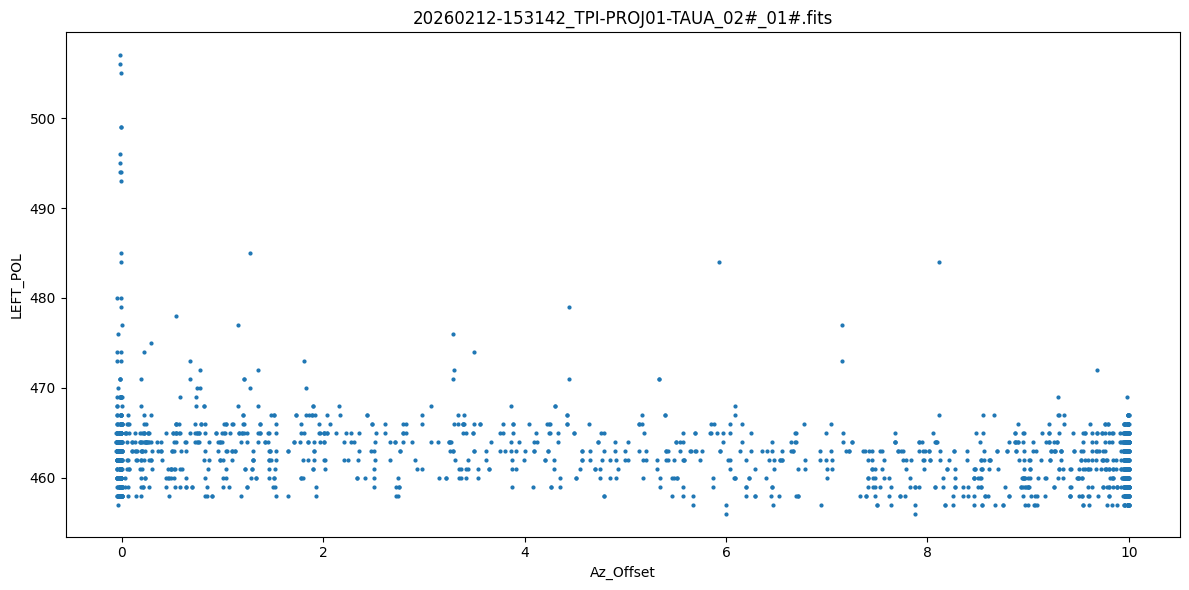

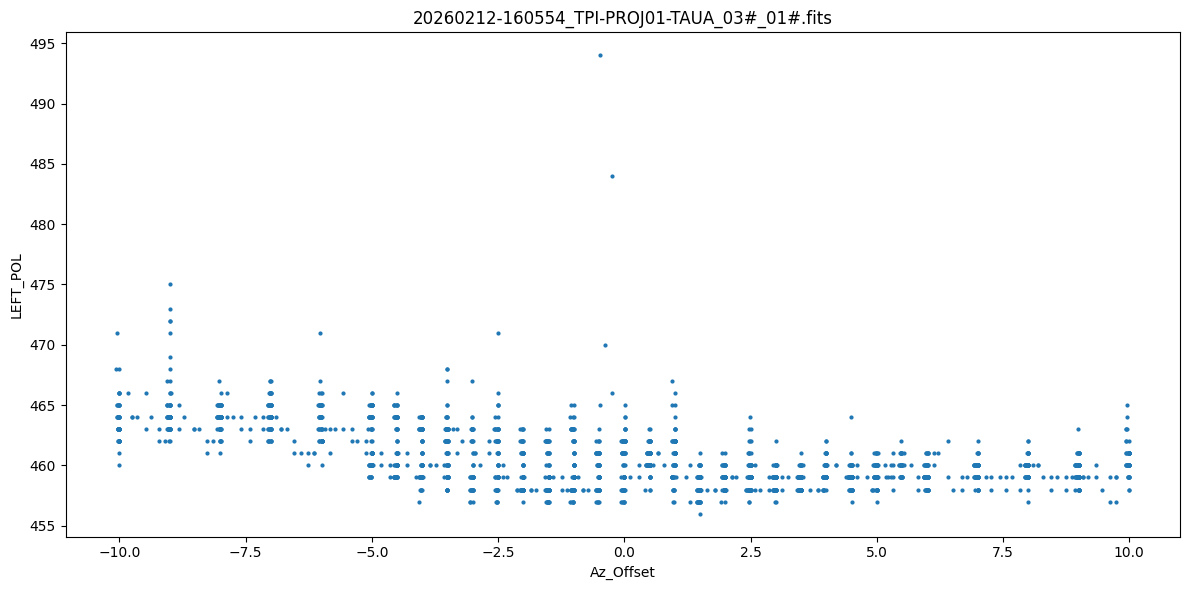

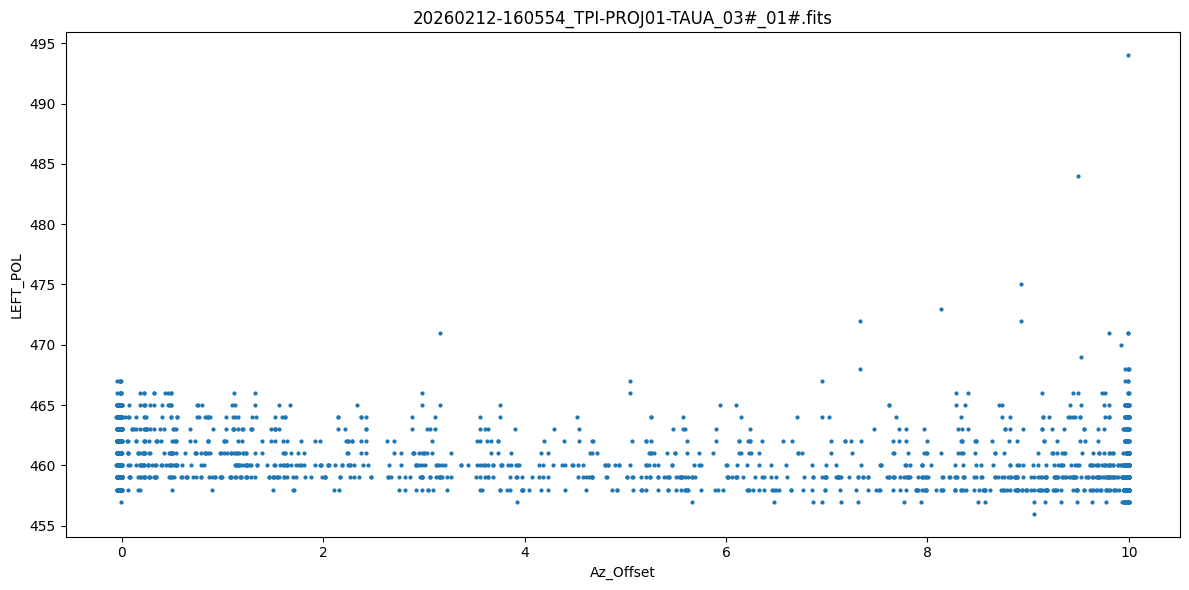

In [4]:
for fname in fits_files2[0:]:
    with fits.open(fname) as hdul:
        data = hdul[1].data
        hdr = hdul[0].header  # Access header from primary HDU (index 0)
        x1 = data["Az_Offset"]
        x2 = data["El_Offset"]
        y = data["LEFT_POL"]
        #t = Time(data["JD"][0], format="jd")
        #time_str = t.iso.split(".")[0]

        plt.figure(figsize=(12,6))
        plt.plot(x1, y, ".", ms=4)
        plt.title(fname.split("/")[-1])
        plt.xlabel("Az_Offset")
        plt.ylabel("LEFT_POL")
        plt.tight_layout()
        plt.show()

        #check the off set range
        plt.figure(figsize=(12,6))
        plt.plot(x2, y, ".", ms=4)
        plt.title(fname.split("/")[-1])
        plt.xlabel("Az_Offset")
        plt.ylabel("LEFT_POL")
        plt.tight_layout()
        plt.show()

# 0212 7 DATA SETs: 5 for SUN 2 for TAU A

In [ ]:
for fname in fits_files2[2:5]:
    with fits.open(fname) as hdul:
        data = hdul[1].data
        hdr = hdul[0].header  # Access header from primary HDU (index 0)
        x1 = data["Az_Offset"]
        x2 = data["El_Offset"]
        y = data["LEFT_POL"]
        t = Time(data["JD"][0], format="jd")
        time_str = t.iso.split(".")[0]
        az = np.median(data["Azimuth"])
        el = np.median(data["Elevation"])



        plt.figure(figsize=(6,4))
        plt.plot(x2, y, ".", ms=4)
        plt.title(fname.split("/")[-1])
        plt.xlabel("El_Offset")
        plt.ylabel("LEFT_POL")
        plt.tight_layout()
        plt.show()

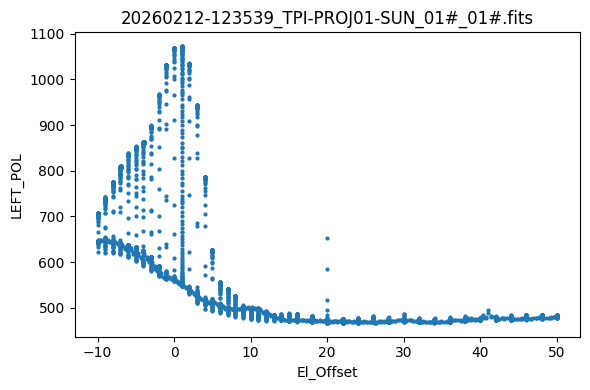

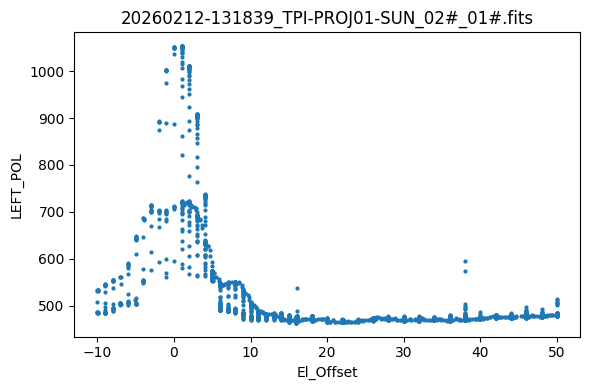

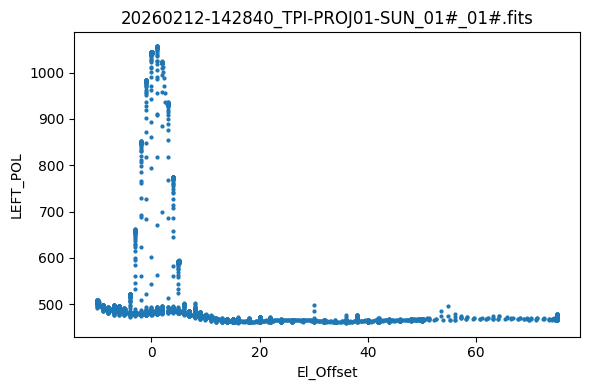

In [ ]:
for fname in fits_files2[2:5]:
    with fits.open(fname) as hdul:
        data = hdul[1].data
        hdr = hdul[0].header  # Access header from primary HDU (index 0)
        x1 = data["Az_Offset"]
        x2 = data["El_Offset"]
        y = data["LEFT_POL"]
        t = Time(data["JD"][0], format="jd")
        time_str = t.iso.split(".")[0]
        az = np.median(data["Azimuth"])
        el = np.median(data["Elevation"])



        plt.figure(figsize=(6,4))
        plt.plot(x2, y, ".", ms=4)
        plt.title(fname.split("/")[-1])
        plt.xlabel("El_Offset")
        plt.ylabel("LEFT_POL")
        plt.tight_layout()
        plt.show()

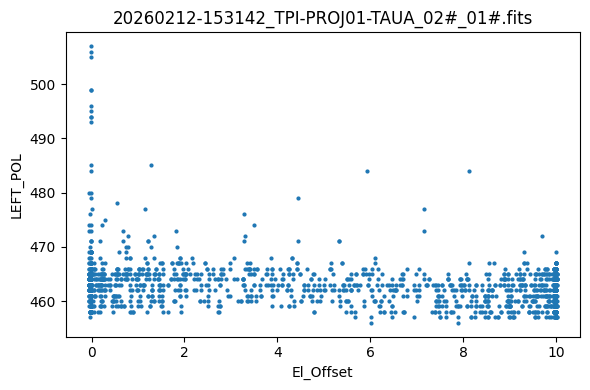

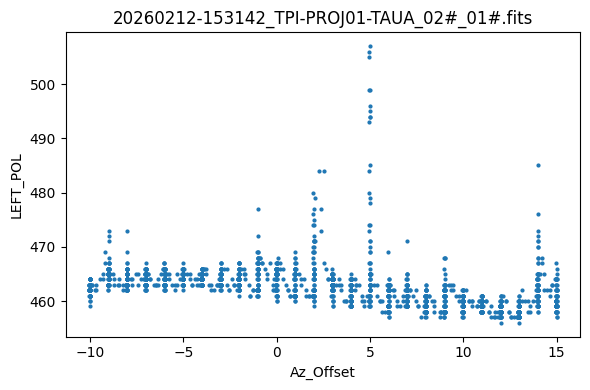

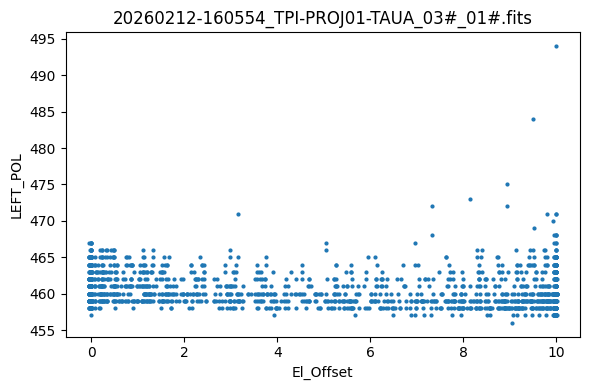

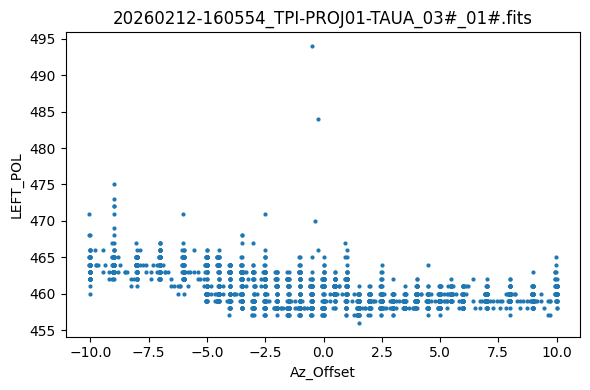

In [ ]:
for fname in fits_files2[5:]:
    with fits.open(fname) as hdul:
        data = hdul[1].data
        hdr = hdul[0].header  # Access header from primary HDU (index 0)
        x1 = data["Az_Offset"]
        x2 = data["El_Offset"]
        y = data["LEFT_POL"]
        t = Time(data["JD"][0], format="jd")
        time_str = t.iso.split(".")[0]
        az = np.median(data["Azimuth"])
        el = np.median(data["Elevation"])



        plt.figure(figsize=(6,4))
        plt.plot(x2, y, ".", ms=4)
        plt.title(fname.split("/")[-1])
        plt.xlabel("El_Offset")
        plt.ylabel("LEFT_POL")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(6,4))
        plt.plot(x1, data["LEFT_POL"], ".", ms=4)
        plt.title(fname.split("/")[-1])
        plt.xlabel("Az_Offset")
        plt.ylabel("LEFT_POL")
        plt.tight_layout()
        plt.show()

# 0211 2 DATA Az

the points are not loacted at the exact degrees need to do some analysis

In [19]:
def read_profile(fname, xc, yc, hdu=1):
    with fits.open(fname) as hdul:
        d = hdul[hdu].data
        x = np.asarray(d[xc], float)
        y = np.asarray(d[yc], float)

    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    idx = np.argsort(x)

    return x[idx], y[idx]



x1, y1 = read_profile(fits_files1[0],xc="Az_Offset",yc="LEFT_POL")

x2, y2 = read_profile(fits_files1[1],xc="Az_Offset",yc="LEFT_POL")


DIAMETER =                    0  / TELESCOPE diameter                            [astropy.io.fits.card]
DIAMETER =                    0  / TELESCOPE diameter                           


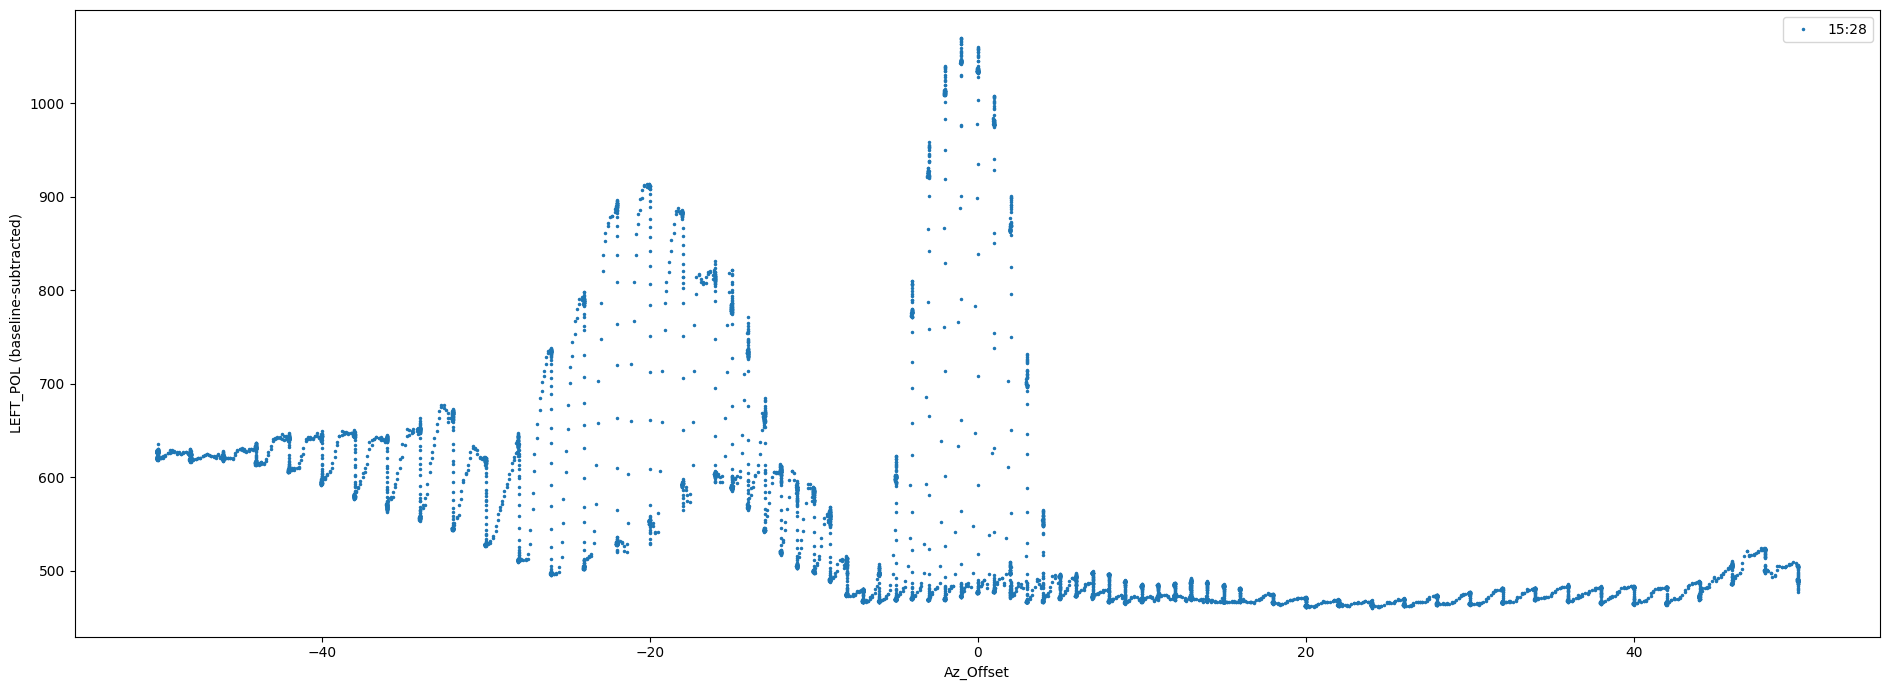

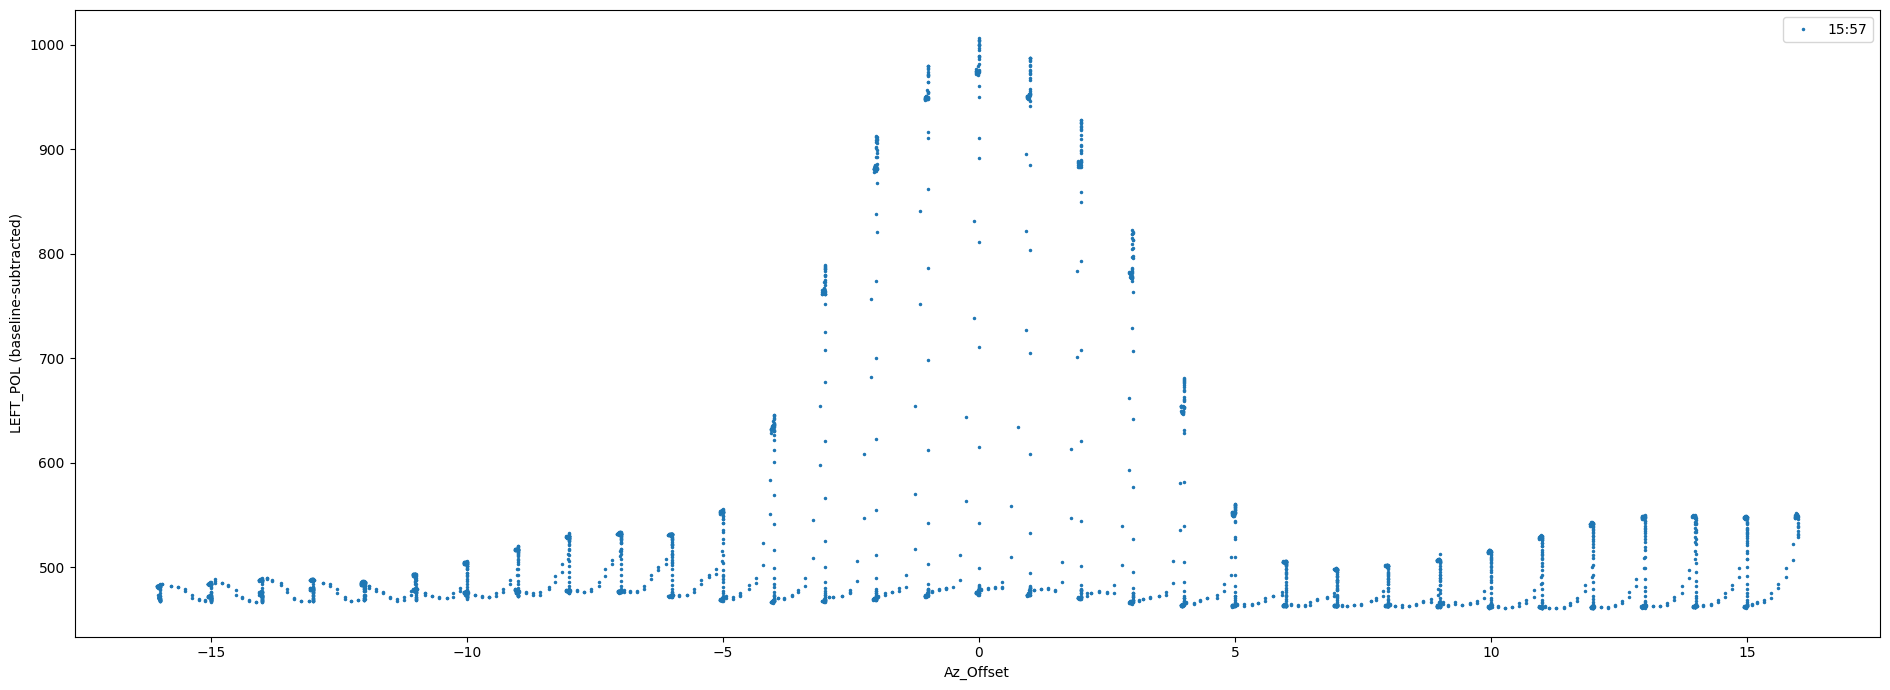

In [20]:
plt.figure(figsize=(19,7))
plt.plot(x1, y1,'.', label="15:28",ms=3)
plt.xlabel("Az_Offset")
plt.ylabel("LEFT_POL (baseline-subtracted)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(19,7))
plt.plot(x2, y2,'.', label="15:57",ms=3)
plt.xlabel("Az_Offset")
plt.ylabel("LEFT_POL (baseline-subtracted)")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
az_target = 15.0
u=x1
u1=np.unique(x1)#remove repeats
d=np.abs(u1 - az_target)
idx=np.argsort(np.abs(u1 - az_target))[:20]
print(np.c_[u1[idx], (u1[idx]-az_target)])

[[ 1.50016600e+01  1.66001683e-03]
 [ 1.50021152e+01  2.11518970e-03]
 [ 1.49916600e+01 -8.33998317e-03]
 [ 1.49909216e+01 -9.07835740e-03]
 [ 1.49904647e+01 -9.53525536e-03]
 [ 1.49891981e+01 -1.08018979e-02]
 [ 1.49887370e+01 -1.12629559e-02]
 [ 1.49882794e+01 -1.17206478e-02]
 [ 1.49877604e+01 -1.22396284e-02]
 [ 1.49870128e+01 -1.29871547e-02]
 [ 1.49865537e+01 -1.34462898e-02]
 [ 1.49860284e+01 -1.39716274e-02]
 [ 1.49855847e+01 -1.44153466e-02]
 [ 1.49852895e+01 -1.47105375e-02]
 [ 1.49848289e+01 -1.51711198e-02]
 [ 1.49843711e+01 -1.56288685e-02]
 [ 1.49838485e+01 -1.61515166e-02]
 [ 1.49831049e+01 -1.68950718e-02]
 [ 1.49826461e+01 -1.73538657e-02]
 [ 1.49821904e+01 -1.78096445e-02]]


In [32]:
# nearest
az_n=u1[np.argmin(d)]
val=y1[x1==az_n]
p_mean = np.mean(val)
p_med = np.median(val)
p_min=np.min(val)
p_max=np.max(val)
N=len(val)

print(p_mean)
print(p_med)
print(p_max)
print(p_min)
print(N)

482.3636363636364
483.0
486.0
478.0
11


In [48]:
def p2p_nearest(x, y, deg_start, deg_stop,k,step=1):
    az_grid = np.arange(deg_start,deg_stop + 1e-12, step, dtype=float)
    p2p = np.full_like(az_grid, np.nan, dtype=float)
    n_used = np.zeros_like(az_grid, dtype=int)


    m=np.isfinite(x) & np.isfinite(y)
    x=np.asarray(x[m], float)
    y=np.asarray(y[m], float)

    for i, az0 in enumerate(az_grid):
        idx=np.argsort(np.abs(x - az0))
        k1=min(k, idx.size)
        if k1 == 0:
            continue
        y1=y[idx[:k1]]

        n_used[i]=k1
        p2p[i]=np.max(y1)-np.min(y1)

    return az_grid, p2p, n_used

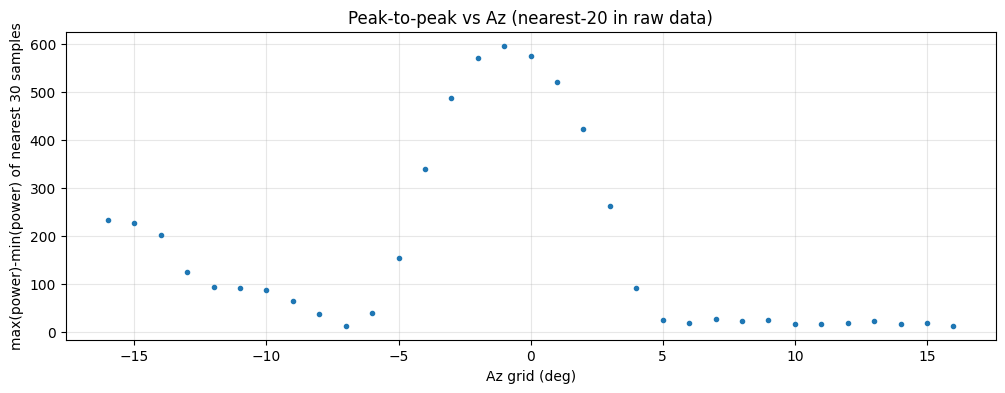

In [49]:
az_grid, p2p, n_used = p2p_nearest(x1, y1,deg_start=-16, deg_stop=16,k=20,step=1)

plt.figure(figsize=(12,4))
plt.plot(az_grid, p2p, ".")
plt.xlabel("Az grid (deg)")
plt.ylabel("max(power)-min(power) of nearest 30 samples")
plt.title("Peak-to-peak vs Az (nearest-20 in raw data)")
plt.grid(alpha=0.3)
plt.show()

In [86]:
def p2p_from_file(fname,x, y,  hdu, deg_start, deg_stop,k,step=1,plot=True):
    if x == "Az_Offset":
        x_name = "Azimuth Offset (degree)"
    elif x == "El_Offset":
        x_name = "Elevation Offset (degree)"
    with fits.open(fname) as hdul:
        d = hdul[hdu].data
        x = np.asarray(d[x], float)
        y = np.asarray(d[y], float)


    az_grid = np.arange(deg_start,deg_stop + 1e-12, step, dtype=float)
    p2p = np.full_like(az_grid, np.nan, dtype=float)
    n_used = np.zeros_like(az_grid, dtype=int)


    m=np.isfinite(x) & np.isfinite(y)
    x=np.asarray(x[m], float)
    y=np.asarray(y[m], float)

    for i, az0 in enumerate(az_grid):
        idx=np.argsort(np.abs(x - az0))
        k1=min(k, idx.size)
        if k1 == 0:
            continue
        y1=y[idx[:k1]]

        n_used[i]=k1
        p2p[i]=np.max(y1)-np.min(y1)

    if plot:
        plt.figure(figsize=(12,4))
        plt.plot(az_grid, p2p, ".")
        plt.xlabel(x_name)
        plt.ylabel("max - min")
        plt.title(fname.split("/")[-1])
        plt.grid(alpha=0.3)
        plt.show()

    return az_grid, p2p

DIAMETER =                    0  / TELESCOPE diameter                            [astropy.io.fits.card]
DIAMETER =                    0  / TELESCOPE diameter                           


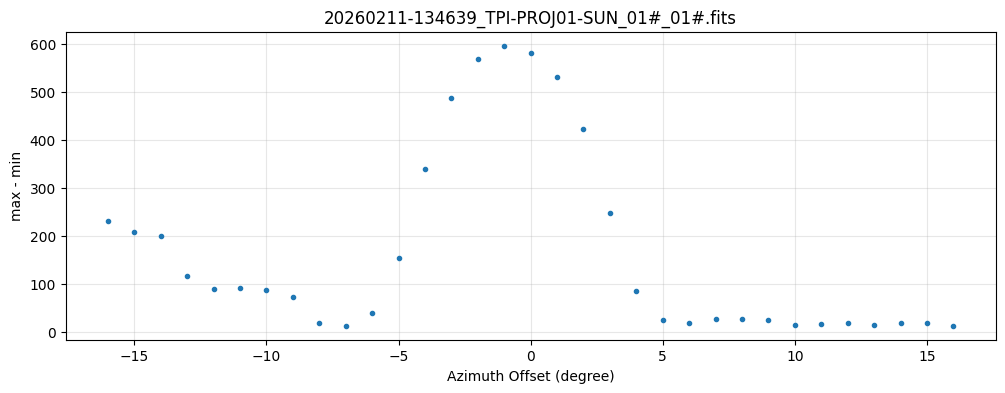

In [87]:
az0, p2p0 = p2p_from_file(fits_files1[0],x="Az_Offset", y="LEFT_POL",hdu=1, deg_start=-16, deg_stop=16,k=20,step=1,plot=True)

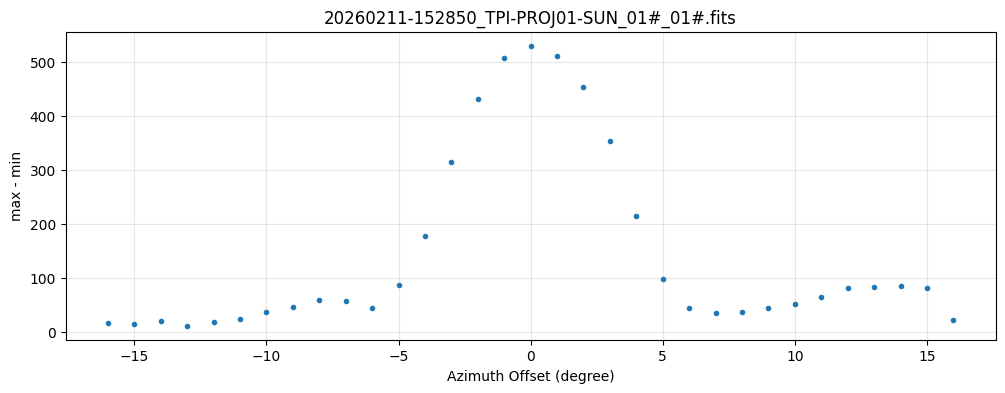

In [88]:
az2, p2p2 = p2p_from_file(fits_files1[1],x="Az_Offset", y="LEFT_POL",hdu=1, deg_start=-16, deg_stop=16,k=20,step=1,plot=True)

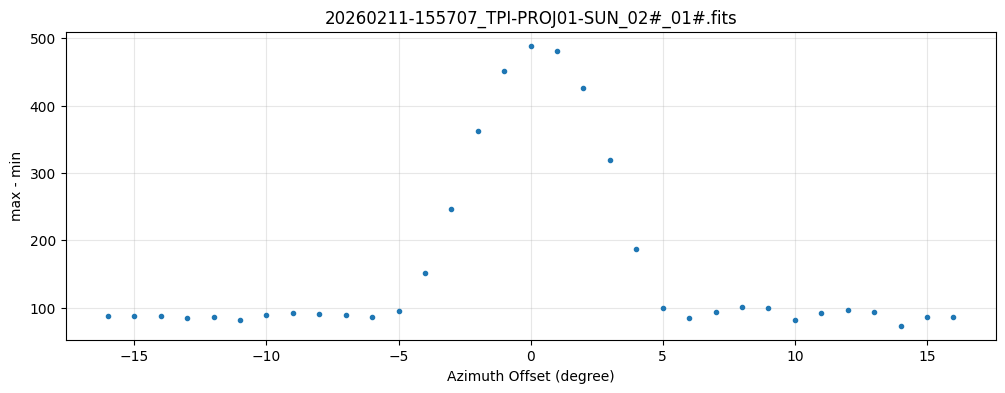

In [89]:
az1, p2p1 = p2p_from_file(fits_files1[2],x="Az_Offset", y="LEFT_POL",hdu=1, deg_start=-16, deg_stop=16,k=20,step=1,plot=True)

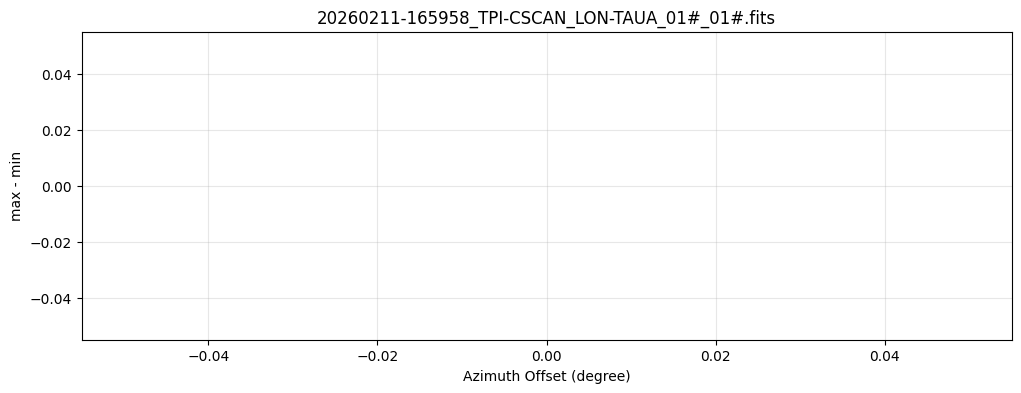

In [90]:
az2, p2p2 = p2p_from_file(fits_files1[4],x="Az_Offset", y="LEFT_POL",hdu=1, deg_start=-16, deg_stop=16,k=20,step=1,plot=True)

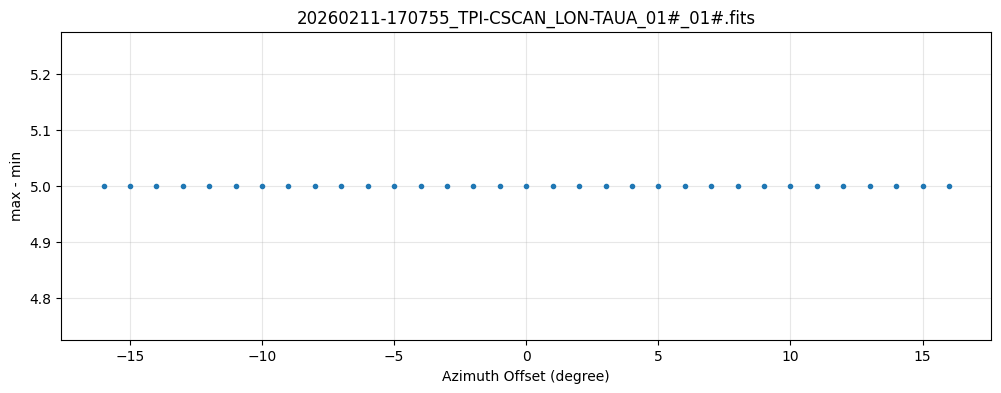

In [91]:
az2, p2p2 = p2p_from_file(fits_files1[5],x="Az_Offset", y="LEFT_POL",hdu=1, deg_start=-16, deg_stop=16,k=20,step=1,plot=True)

# 0212 3 DATA El

the points are not loacted at the exact degrees need to do some analysis

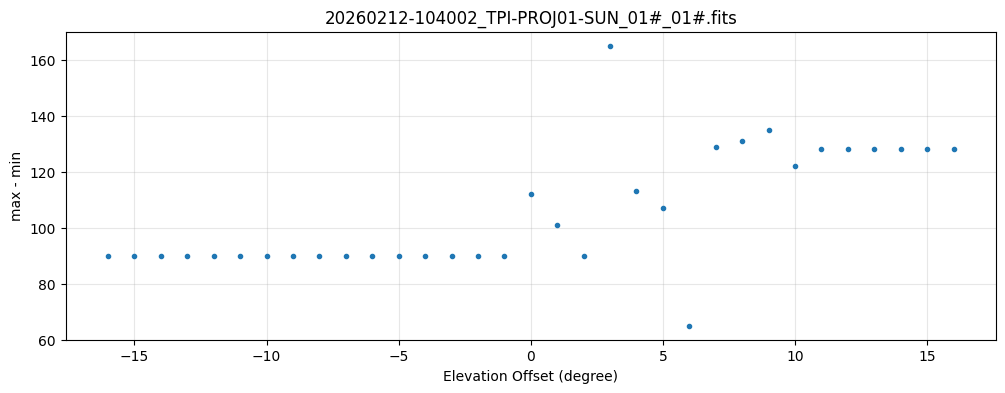

In [92]:
az0, p2p0 = p2p_from_file(fits_files2[0],x="El_Offset", y="LEFT_POL",hdu=1, deg_start=-16, deg_stop=16,k=20,step=1,plot=True)

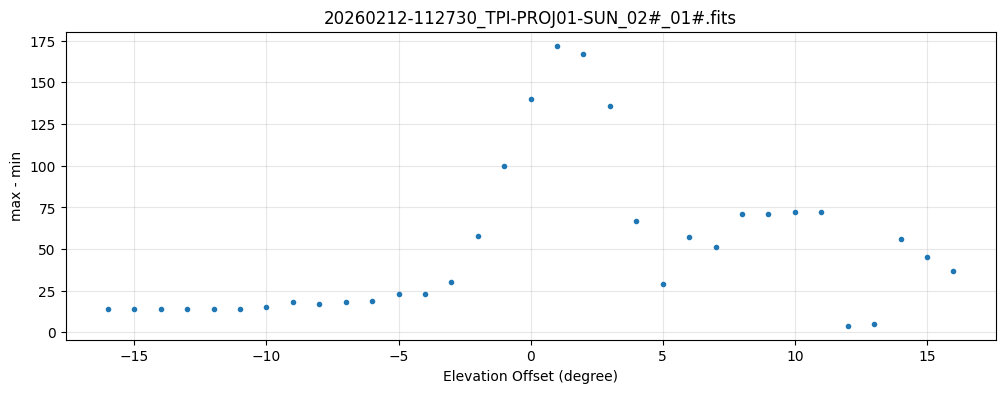

In [93]:
az0, p2p0 = p2p_from_file(fits_files2[1],x="El_Offset", y="LEFT_POL",hdu=1, deg_start=-16, deg_stop=16,k=20,step=1,plot=True)

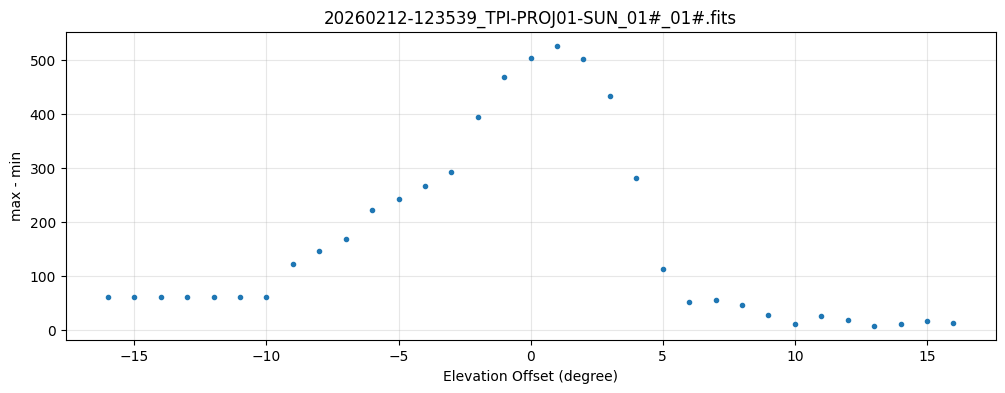

In [94]:
az0, p2p0 = p2p_from_file(fits_files2[2],x="El_Offset", y="LEFT_POL",hdu=1, deg_start=-16, deg_stop=16,k=20,step=1,plot=True)

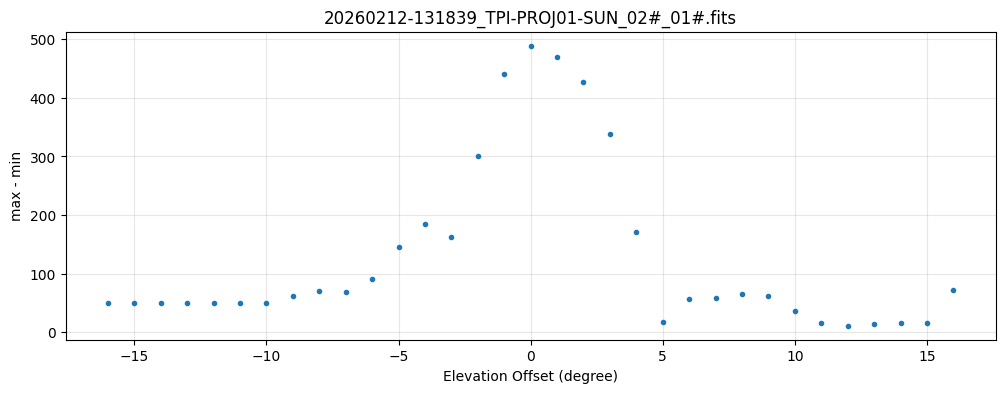

In [95]:
az0, p2p0 = p2p_from_file(fits_files2[3],x="El_Offset", y="LEFT_POL",hdu=1, deg_start=-16, deg_stop=16,k=20,step=1,plot=True)

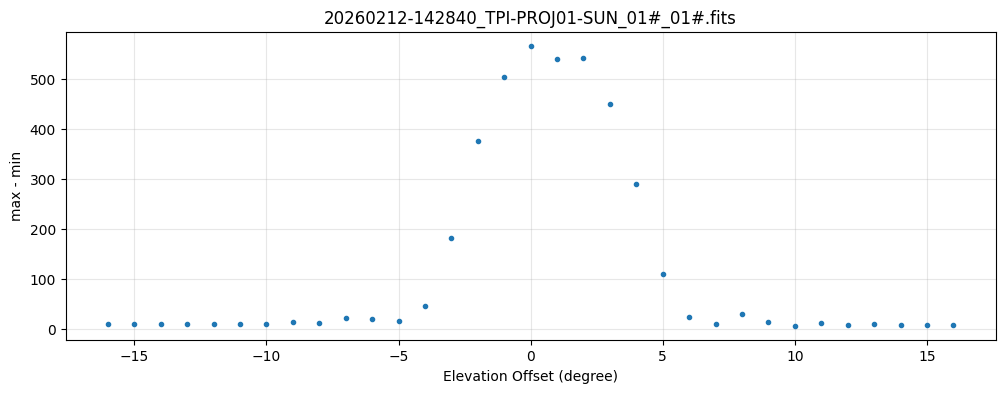

In [96]:
az0, p2p0 = p2p_from_file(fits_files2[4],x="El_Offset", y="LEFT_POL",hdu=1, deg_start=-16, deg_stop=16,k=20,step=1,plot=True)

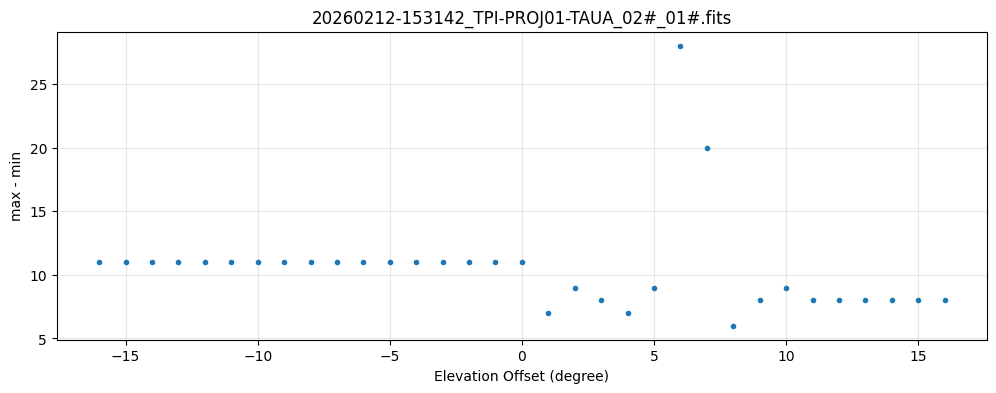

In [97]:
az0, p2p0 = p2p_from_file(fits_files2[5],x="El_Offset", y="LEFT_POL",hdu=1, deg_start=-16, deg_stop=16,k=20,step=1,plot=True)

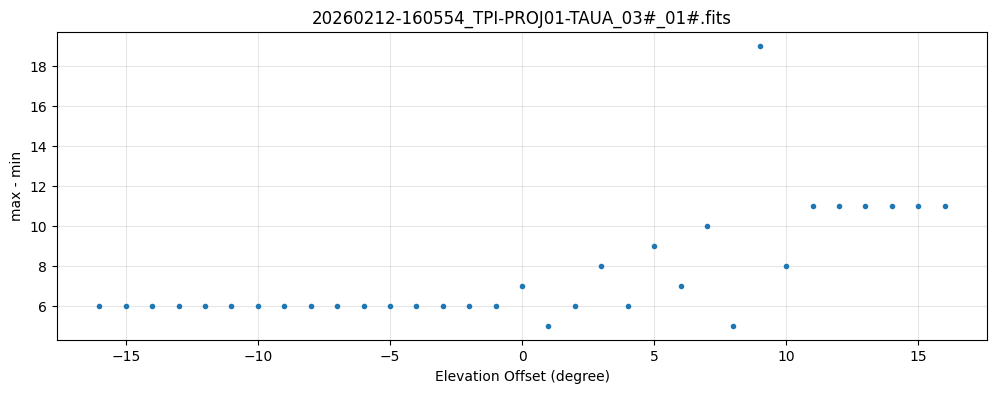

In [98]:
az0, p2p0 = p2p_from_file(fits_files2[6],x="El_Offset", y="LEFT_POL",hdu=1, deg_start=-16, deg_stop=16,k=20,step=1,plot=True)

Obvious peaks but not really good shape for TAUA